In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 0. Libraries Import and API Setup

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import getpass
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
import copy
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score, confusion_matrix, average_precision_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
#kaggle_token = getpass.getpass("Enter Kaggle API token: ")

#os.environ["KAGGLE_API_TOKEN"] = kaggle_token

# 1. Data Import

In [ ]:
BASE_DIR = "/content/drive/MyDrive/self learning/Self Project/Credit Rating Model/dataset/home_credit_subset/"

In [ ]:
# os.makedirs(dataset_dir, exist_ok=True)

# Check if dataset already exists
#if len(os.listdir(dataset_dir)) == 0:
#    print("Dataset not found. Downloading...")
#    path = kagglehub.dataset_download("megancrenshaw/home-credit-default-risk")

    # Copy files to dataset_dir
    #for item in os.listdir(path):
        #src = os.path.join(path, item)
        #dst = os.path.join(dataset_dir, item)
        #if os.path.isdir(src):
        #    shutil.copytree(src, dst, dirs_exist_ok=True)
        #else:
        #    shutil.copy2(src, dst)
    #print("Dataset copied to:", dataset_dir)
#else:
    #print("Dataset already exists at:", dataset_dir)

#print("Files:", os.listdir(dataset_dir))

In [6]:
def safe_read_csv(base_dir, filename, usecols=None, dtype=None):
    path = os.path.join(base_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path, usecols=usecols, dtype=dtype)

# Only load columns needed
app_cols = ["SK_ID_CURR", "TARGET"]

pos_cols = [
    "SK_ID_CURR", "SK_ID_PREV", "MONTHS_BALANCE",
    "SK_DPD", "CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE",
    "NAME_CONTRACT_STATUS"
]

cc_cols = [
    "SK_ID_CURR", "SK_ID_PREV", "MONTHS_BALANCE",
    "SK_DPD", "AMT_PAYMENT_CURRENT", "AMT_BALANCE",
    "AMT_INST_MIN_REGULARITY", "NAME_CONTRACT_STATUS"
]

inst_cols = [
    "SK_ID_CURR", "SK_ID_PREV",
    "NUM_INSTALMENT_NUMBER", "DAYS_INSTALMENT",
    "DAYS_ENTRY_PAYMENT", "AMT_INSTALMENT", "AMT_PAYMENT"
]

bureau_cols = ["SK_ID_BUREAU", "SK_ID_CURR"]
bureau_balance_cols = ["SK_ID_BUREAU", "MONTHS_BALANCE", "STATUS"]

application_train = safe_read_csv(BASE_DIR, "application_train.csv", usecols=app_cols)
pos_cash = safe_read_csv(BASE_DIR, "POS_CASH_balance.csv", usecols=pos_cols)
credit_card = safe_read_csv(BASE_DIR, "credit_card_balance.csv", usecols=cc_cols)
installments = safe_read_csv(BASE_DIR, "installments_payments.csv", usecols=inst_cols)
bureau = safe_read_csv(BASE_DIR, "bureau.csv", usecols=bureau_cols)
bureau_balance = safe_read_csv(BASE_DIR, "bureau_balance.csv", usecols=bureau_balance_cols)

print("Loaded shapes:")
print("application_train:", application_train.shape)
print("pos_cash         :", pos_cash.shape)
print("credit_card      :", credit_card.shape)
print("installments     :", installments.shape)
print("bureau           :", bureau.shape)
print("bureau_balance   :", bureau_balance.shape)

Loaded shapes:
application_train: (25000, 2)
pos_cash         : (674275, 7)
credit_card      : (192268, 8)
installments     : (863385, 7)
bureau           : (119939, 2)
bureau_balance   : (1204499, 3)


In [7]:
# Application dataframe
application_train

,SK_ID_CURR,TARGET
0,338068,0
1,237162,0
2,287122,0
3,443082,0
4,207341,1
...,...,...
24995,245931,0
24996,299566,0
24997,327344,0
24998,176157,0


In [8]:
# POS CASH balance dataframe
pos_cash

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD
0,1059679,139637,-31,12.0,12.0,Active,0
1,1050971,220814,-33,18.0,12.0,Active,0
2,2165412,239703,-35,12.0,12.0,Signed,0
3,1948420,256319,-35,24.0,7.0,Active,0
4,2698168,445811,-35,24.0,9.0,Active,0
...,...,...,...,...,...,...,...
674270,1412481,399319,-37,24.0,2.0,Active,0
674271,2478913,392078,-41,24.0,1.0,Active,0
674272,2478913,392078,-42,24.0,2.0,Active,0
674273,1301296,317062,-19,10.0,0.0,Active,740


In [9]:
# Credit Card balance dataframe
credit_card

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,NAME_CONTRACT_STATUS,SK_DPD
0,1441883,171537,-5,0.000,12218.490,2607.795,Active,0
1,2016842,302450,-3,0.000,0.000,0.000,Completed,0
2,2014169,147323,-4,45403.110,5432.625,22500.000,Active,0
3,2408643,104761,-4,0.000,0.000,NaN,Active,0
4,1916109,262878,-5,300314.880,16844.400,21600.000,Active,0
...,...,...,...,...,...,...,...,...
192263,2795321,375426,-9,300499.245,15157.035,0.000,Active,0
192264,1176531,173687,-8,435339.090,23241.645,23400.000,Active,0
192265,1494443,365834,-7,0.000,0.000,NaN,Active,0
192266,1614446,104421,-10,0.000,118.665,2.115,Active,0


In [10]:
# Installments payments dataframe
installments

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1770345,128334,5,-240.0,-255.0,10649.925,10649.925
1,2671380,111601,7,-540.0,-548.0,8109.765,8109.765
2,2632598,169863,65,-912.0,-912.0,349.830,349.830
3,1254935,138262,41,-1176.0,-1187.0,9000.000,9000.000
4,2740963,128715,2,-1615.0,-1618.0,8829.405,8829.405
...,...,...,...,...,...,...,...
863380,1948199,440380,4,-558.0,-559.0,17495.550,17495.550
863381,2772819,420599,9,-1368.0,-1377.0,4805.550,4805.550
863382,2831819,417123,8,-15.0,NaN,4399.740,NaN
863383,2448869,434321,16,-117.0,NaN,11504.250,NaN


In [11]:
# Bureau balance dataframe
bureau_balance

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715529,-58,C
1,5715529,-59,C
2,5715529,-60,C
3,5715529,-61,0
4,5715529,-62,X
...,...,...,...
1204494,5023816,-44,1
1204495,5023816,-45,0
1204496,5023816,-46,0
1204497,5023816,-47,0


# 2. Data Cleaning

## 2.1 Handling Missing Values

In [26]:
# POS_CASH
pos_cash_clean = pos_cash.copy()
pos_cash_clean = pos_cash_clean.sort_values(["SK_ID_CURR", "SK_ID_PREV", "MONTHS_BALANCE"])

pos_cash_clean["CNT_INSTALMENT_missing_flag"] = pos_cash_clean["CNT_INSTALMENT"].isna().astype(int)
pos_cash_clean["CNT_INSTALMENT_FUTURE_missing_flag"] = pos_cash_clean["CNT_INSTALMENT_FUTURE"].isna().astype(int)

pos_cash_clean["CNT_INSTALMENT"] = (
    pos_cash_clean.groupby(["SK_ID_CURR", "SK_ID_PREV"])["CNT_INSTALMENT"]
    .ffill()
    .fillna(0)
)

pos_cash_clean["CNT_INSTALMENT_FUTURE"] = (
    pos_cash_clean.groupby(["SK_ID_CURR", "SK_ID_PREV"])["CNT_INSTALMENT_FUTURE"]
    .ffill()
    .fillna(0)
)

pos_cash_clean["pos_delinquent_flag"] = (pos_cash_clean["SK_DPD"] > 0).astype(int)

In [27]:
credit_card_clean = credit_card.copy()
credit_card_clean = credit_card_clean.sort_values(["SK_ID_CURR", "SK_ID_PREV", "MONTHS_BALANCE"])

for col in ["AMT_PAYMENT_CURRENT", "AMT_BALANCE", "AMT_INST_MIN_REGULARITY"]:
    credit_card_clean[f"{col}_missing_flag"] = credit_card_clean[col].isna().astype(int)

credit_card_clean["AMT_PAYMENT_CURRENT"] = credit_card_clean["AMT_PAYMENT_CURRENT"].fillna(0)
credit_card_clean["AMT_BALANCE"] = credit_card_clean["AMT_BALANCE"].fillna(0)
credit_card_clean["AMT_INST_MIN_REGULARITY"] = credit_card_clean["AMT_INST_MIN_REGULARITY"].fillna(0)

credit_card_clean["cc_delinquent_flag"] = (credit_card_clean["SK_DPD"] > 0).astype(int)
credit_card_clean["cc_pay_to_bal_ratio"] = (
    credit_card_clean["AMT_PAYMENT_CURRENT"] / (credit_card_clean["AMT_BALANCE"] + 1)
)

In [28]:
installments_clean = installments.copy()

installments_clean["miss_days_entry_payment"] = installments_clean["DAYS_ENTRY_PAYMENT"].isna().astype(int)
installments_clean["miss_amt_payment"] = installments_clean["AMT_PAYMENT"].isna().astype(int)

installments_clean["AMT_PAYMENT"] = installments_clean["AMT_PAYMENT"].fillna(0)
installments_clean["DAYS_ENTRY_PAYMENT_FILLED"] = installments_clean["DAYS_ENTRY_PAYMENT"].fillna(
    installments_clean["DAYS_INSTALMENT"]
)

installments_clean["payment_delay_days"] = (
    installments_clean["DAYS_ENTRY_PAYMENT_FILLED"] - installments_clean["DAYS_INSTALMENT"]
)
installments_clean["late_payment_flag"] = (installments_clean["payment_delay_days"] > 0).astype(int)

installments_clean["underpayment_amount"] = (
    installments_clean["AMT_INSTALMENT"] - installments_clean["AMT_PAYMENT"]
).clip(lower=0)
installments_clean["underpayment_flag"] = (installments_clean["underpayment_amount"] > 0).astype(int)

# create borrower-month bucket for sequence panel
installments_clean["MONTHS_BALANCE"] = -np.floor(
    np.abs(installments_clean["DAYS_INSTALMENT"]) / 30
).astype(int)


In [29]:
bureau_balance_clean = bureau_balance.copy()

bureau_balance_clean["bureau_delinquent_flag"] = bureau_balance_clean["STATUS"].isin(
    ["1", "2", "3", "4", "5"]
).astype(int)
bureau_balance_clean["bureau_status_0_flag"] = (bureau_balance_clean["STATUS"] == "0").astype(int)
bureau_balance_clean["bureau_closed_flag"] = (bureau_balance_clean["STATUS"] == "C").astype(int)
bureau_balance_clean["bureau_no_loan_flag"] = (bureau_balance_clean["STATUS"] == "X").astype(int)

# link bureau_balance to borrower
bureau_balance_clean = bureau_balance_clean.merge(
    bureau,
    on="SK_ID_BUREAU",
    how="left"
)

print("Cleaning complete.")
print("pos_cash_clean        :", pos_cash_clean.shape)
print("credit_card_clean     :", credit_card_clean.shape)
print("installments_clean    :", installments_clean.shape)
print("bureau_balance_clean  :", bureau_balance_clean.shape)

Cleaning complete.
pos_cash_clean        : (674275, 10)
credit_card_clean     : (192268, 13)
installments_clean    : (863385, 15)
bureau_balance_clean  : (1204499, 8)


# 3. EDA - Temporal Patterns for Temporal

## 3.1 Borrower-month source tables

In [30]:
pos_m = pos_cash_clean[["SK_ID_CURR", "MONTHS_BALANCE"]].dropna().drop_duplicates()
cc_m = credit_card_clean[["SK_ID_CURR", "MONTHS_BALANCE"]].dropna().drop_duplicates()
bureau_m = bureau_balance_clean[["SK_ID_CURR", "MONTHS_BALANCE"]].dropna().drop_duplicates()
inst_m = installments_clean[["SK_ID_CURR", "MONTHS_BALANCE"]].dropna().drop_duplicates()

## 3.2 Combined borrower-month skeleton

In [31]:
panel = pd.concat(
    [
        pos_m.assign(src_pos=1),
        cc_m.assign(src_cc=1),
        bureau_m.assign(src_bureau=1),
        inst_m.assign(src_inst=1),
    ],
    ignore_index=True
)

panel = (
    panel.groupby(["SK_ID_CURR", "MONTHS_BALANCE"], as_index=False)
    .agg({
        "src_pos": "max",
        "src_cc": "max",
        "src_bureau": "max",
        "src_inst": "max"
    })
    .fillna(0)
)

for col in ["src_pos", "src_cc", "src_bureau", "src_inst"]:
    panel[col] = panel[col].astype(int)

panel_hist = (
    panel.groupby("SK_ID_CURR")["MONTHS_BALANCE"]
    .nunique()
    .reset_index(name="n_months_panel")
)

print("Combined panel history length:")
print(panel_hist["n_months_panel"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

print(f"Borrowers with >= 12 panel months: {(panel_hist['n_months_panel'] >= 12).sum():,}")
print(f"Borrowers with >= 24 panel months: {(panel_hist['n_months_panel'] >= 24).sum():,}")

Combined panel history length:
count    23936.000000
mean        39.426471
std         27.343843
min          1.000000
25%         16.000000
50%         32.000000
75%         58.000000
90%         86.000000
95%         92.000000
max         97.000000
Name: n_months_panel, dtype: float64
Borrowers with >= 12 panel months: 20,569
Borrowers with >= 24 panel months: 14,975


## 3.3 Last-12-month coverage

In [32]:
panel_last12 = panel[(panel["MONTHS_BALANCE"] >= -11) & (panel["MONTHS_BALANCE"] <= 0)].copy()

last12_hist = (
    panel_last12.groupby("SK_ID_CURR")["MONTHS_BALANCE"]
    .nunique()
    .reset_index(name="n_months_last12")
)

print("\nLast-12-month coverage:")
print(last12_hist["n_months_last12"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print(f"Borrowers with full 12/12 recent months: {(last12_hist['n_months_last12'] == 12).sum():,}")
print(f"Borrowers with at least 6/12 months    : {(last12_hist['n_months_last12'] >= 6).sum():,}")


Last-12-month coverage:
count    20180.000000
mean        10.145986
std          2.935603
min          1.000000
25%          9.000000
50%         12.000000
75%         12.000000
90%         12.000000
95%         12.000000
max         12.000000
Name: n_months_last12, dtype: float64
Borrowers with full 12/12 recent months: 11,778
Borrowers with at least 6/12 months    : 17,968


## 3.4 Borrower eligibility

In [33]:
eligible_ids = set(
    last12_hist.loc[last12_hist["n_months_last12"] >= 6, "SK_ID_CURR"]
)

print(f"\nEligible borrowers for Option B (>=6 of last 12 months): {len(eligible_ids):,}")
print(f"Eligibility rate: {len(eligible_ids) / application_train['SK_ID_CURR'].nunique():.2%}")


Eligible borrowers for Option B (>=6 of last 12 months): 17,968
Eligibility rate: 71.87%


Temporal data across all four sources spans 96 months of rich payment behavior, with low but meaningful delay rates (2.95-3.07%) that predominantly occur in late-stage contracts, providing strong temporal signals for the Temporal to distinguish between healthy borrowers and default-risk customers. The dominance of on-time payments (97%) combined with the concentration of delays in near-completion contracts creates distinct temporal patterns that align perfectly with the Temporal's ability to capture payment trajectory deterioration as a default indicator.

# 4. Feature Engineering - Temporal Temporal Features (Stream 1)

## 4.1 Monthly feature engineering per source

In [34]:
# POS monthly features
pos_monthly = (
    pos_cash_clean.groupby(["SK_ID_CURR", "MONTHS_BALANCE"])
    .agg(
        pos_dpd_max=("SK_DPD", "max"),
        pos_dpd_mean=("SK_DPD", "mean"),
        pos_any_dpd=("pos_delinquent_flag", "max"),
        pos_cnt_instalment_mean=("CNT_INSTALMENT", "mean"),
        pos_cnt_future_mean=("CNT_INSTALMENT_FUTURE", "mean"),
        pos_missing_cnt_rate=("CNT_INSTALMENT_missing_flag", "mean"),
        pos_missing_future_rate=("CNT_INSTALMENT_FUTURE_missing_flag", "mean"),
    )
    .reset_index()
)

# CREDIT_CARD monthly features
cc_monthly = (
    credit_card_clean.groupby(["SK_ID_CURR", "MONTHS_BALANCE"])
    .agg(
        cc_dpd_max=("SK_DPD", "max"),
        cc_dpd_mean=("SK_DPD", "mean"),
        cc_any_dpd=("cc_delinquent_flag", "max"),
        cc_payment_sum=("AMT_PAYMENT_CURRENT", "sum"),
        cc_balance_mean=("AMT_BALANCE", "mean"),
        cc_min_inst_mean=("AMT_INST_MIN_REGULARITY", "mean"),
        cc_pay_to_bal_ratio_mean=("cc_pay_to_bal_ratio", "mean"),
        cc_payment_missing_rate=("AMT_PAYMENT_CURRENT_missing_flag", "mean"),
    )
    .reset_index()
)

# INSTALLMENTS monthly features
inst_monthly = (
    installments_clean.groupby(["SK_ID_CURR", "MONTHS_BALANCE"])
    .agg(
        inst_payment_sum=("AMT_PAYMENT", "sum"),
        inst_payment_mean=("AMT_PAYMENT", "mean"),
        inst_late_rate=("late_payment_flag", "mean"),
        inst_delay_mean=("payment_delay_days", "mean"),
        inst_delay_max=("payment_delay_days", "max"),
        inst_underpay_sum=("underpayment_amount", "sum"),
        inst_underpay_rate=("underpayment_flag", "mean"),
        inst_missing_entry_rate=("miss_days_entry_payment", "mean"),
        inst_missing_amt_rate=("miss_amt_payment", "mean"),
    )
    .reset_index()
)

# BUREAU monthly features
bureau_monthly = (
    bureau_balance_clean.groupby(["SK_ID_CURR", "MONTHS_BALANCE"])
    .agg(
        bureau_any_delinquent=("bureau_delinquent_flag", "max"),
        bureau_delinquency_rate=("bureau_delinquent_flag", "mean"),
        bureau_status0_rate=("bureau_status_0_flag", "mean"),
        bureau_closed_rate=("bureau_closed_flag", "mean"),
        bureau_no_loan_rate=("bureau_no_loan_flag", "mean"),
    )
    .reset_index()
)

print("Monthly source feature shapes:")
print("pos_monthly   :", pos_monthly.shape)
print("cc_monthly    :", cc_monthly.shape)
print("inst_monthly  :", inst_monthly.shape)
print("bureau_monthly:", bureau_monthly.shape)

Monthly source feature shapes:
pos_monthly   : (577771, 9)
cc_monthly    : (192062, 10)
inst_monthly  : (618567, 11)
bureau_monthly: (397509, 7)


## 4.2 Merge monthly sources into borrower-month panel

In [35]:
monthly_panel = pos_monthly.merge(
    cc_monthly, on=["SK_ID_CURR", "MONTHS_BALANCE"], how="outer"
).merge(
    inst_monthly, on=["SK_ID_CURR", "MONTHS_BALANCE"], how="outer"
).merge(
    bureau_monthly, on=["SK_ID_CURR", "MONTHS_BALANCE"], how="outer"
)

monthly_panel = monthly_panel.sort_values(["SK_ID_CURR", "MONTHS_BALANCE"]).reset_index(drop=True)

# source presence flags
monthly_panel["src_pos"] = monthly_panel["pos_dpd_max"].notna().astype(int)
monthly_panel["src_cc"] = monthly_panel["cc_dpd_max"].notna().astype(int)
monthly_panel["src_inst"] = monthly_panel["inst_payment_sum"].notna().astype(int)
monthly_panel["src_bureau"] = monthly_panel["bureau_any_delinquent"].notna().astype(int)

# keep only recent 12 months
monthly_panel = monthly_panel[
    (monthly_panel["MONTHS_BALANCE"] >= -11) & (monthly_panel["MONTHS_BALANCE"] <= 0)
].copy()

print("monthly_panel shape:", monthly_panel.shape)
print(monthly_panel.head())

monthly_panel shape: (204746, 35)
    SK_ID_CURR  MONTHS_BALANCE  pos_dpd_max  pos_dpd_mean  pos_any_dpd  \
21      100009             -11          0.0           0.0          0.0   
22      100009             -10          0.0           0.0          0.0   
23      100009              -9          0.0           0.0          0.0   
24      100009              -8          0.0           0.0          0.0   
25      100009              -7          0.0           0.0          0.0   

    pos_cnt_instalment_mean  pos_cnt_future_mean  pos_missing_cnt_rate  \
21                     12.0             9.000000                   0.0   
22                      8.0             6.666667                   0.0   
23                      8.0             5.333333                   0.0   
24                      8.0             4.666667                   0.0   
25                      8.0             3.666667                   0.0   

    pos_missing_future_rate  cc_dpd_max  ...  inst_missing_amt_rate  \
21   

## 4.3 Filter eligible borrowers

In [36]:
coverage_last12 = (
    monthly_panel.groupby("SK_ID_CURR")["MONTHS_BALANCE"]
    .nunique()
    .reset_index(name="n_months_last12")
)

eligible_ids = set(
    coverage_last12.loc[coverage_last12["n_months_last12"] >= 6, "SK_ID_CURR"]
)

monthly_panel = monthly_panel[monthly_panel["SK_ID_CURR"].isin(eligible_ids)].copy()
application_seq = application_train[application_train["SK_ID_CURR"].isin(eligible_ids)].copy()

print("Eligible borrowers:", len(eligible_ids))
print("monthly_panel filtered shape:", monthly_panel.shape)
print("application_seq shape:", application_seq.shape)

Eligible borrowers: 17968
monthly_panel filtered shape: (197422, 35)
application_seq shape: (17968, 2)


## 4.4 Build fixed 12-step sequence with padding + mask

In [37]:
feature_cols = [col for col in monthly_panel.columns if col not in ["SK_ID_CURR", "MONTHS_BALANCE"]]

# full 12-month template
month_template = pd.DataFrame({"MONTHS_BALANCE": list(range(-11, 1))})

borrower_frames = []
for sk_id, grp in monthly_panel.groupby("SK_ID_CURR"):
    tmp = month_template.merge(
        grp,
        on="MONTHS_BALANCE",
        how="left"
    )
    tmp["SK_ID_CURR"] = sk_id
    tmp["time_mask"] = tmp[feature_cols].notna().any(axis=1).astype(int)
    borrower_frames.append(tmp)

seq_panel = pd.concat(borrower_frames, ignore_index=True)

# fill missing monthly features with 0 after mask creation
seq_panel[feature_cols] = seq_panel[feature_cols].fillna(0)

print("seq_panel shape:", seq_panel.shape)
print(seq_panel.head(15))

seq_panel shape: (215616, 36)
    MONTHS_BALANCE  SK_ID_CURR  pos_dpd_max  pos_dpd_mean  pos_any_dpd  \
0              -11      100009          0.0           0.0          0.0   
1              -10      100009          0.0           0.0          0.0   
2               -9      100009          0.0           0.0          0.0   
3               -8      100009          0.0           0.0          0.0   
4               -7      100009          0.0           0.0          0.0   
5               -6      100009          0.0           0.0          0.0   
6               -5      100009          0.0           0.0          0.0   
7               -4      100009          0.0           0.0          0.0   
8               -3      100009          0.0           0.0          0.0   
9               -2      100009          0.0           0.0          0.0   
10              -1      100009          0.0           0.0          0.0   
11               0      100009          0.0           0.0          0.0   
12      

## 4.5 Convert to TCN-ready tensors

In [38]:
borrower_ids = sorted(seq_panel["SK_ID_CURR"].unique())

X_seq_list = []
X_mask_list = []

for sk_id in borrower_ids:
    g = seq_panel[seq_panel["SK_ID_CURR"] == sk_id].sort_values("MONTHS_BALANCE")
    X_seq_list.append(g[feature_cols].values)
    X_mask_list.append(g["time_mask"].values.reshape(-1, 1))

X_seq = np.stack(X_seq_list)          # shape: (N, 12, F)
X_mask = np.stack(X_mask_list)        # shape: (N, 12, 1)

y_seq = (
    application_seq.set_index("SK_ID_CURR")
    .loc[borrower_ids, "TARGET"]
    .values
)

print("X_seq shape :", X_seq.shape)
print("X_mask shape:", X_mask.shape)
print("y_seq shape :", y_seq.shape)

X_seq shape : (17968, 12, 33)
X_mask shape: (17968, 12, 1)
y_seq shape : (17968,)


# 5. Feature Engineering - Static Features (Stream 2 - No Data Leakage)

## 5.1 Load full static application data for eligible borrowers

In [39]:
app_full = safe_read_csv(BASE_DIR, "application_train.csv")  # full columns

# Keep only borrowers eligible for sequence model
app_static = app_full[app_full["SK_ID_CURR"].isin(eligible_ids)].copy()

print("Static application overview (eligible borrowers only):")
print(f"Shape: {app_static.shape}")
print(f"Columns: {len(app_static.columns)}")
print(f"Unique borrowers: {app_static['SK_ID_CURR'].nunique()}")
print(f"Target distribution:\n{app_static['TARGET'].value_counts(normalize=True)}\n")

Static application overview (eligible borrowers only):
Shape: (17968, 122)
Columns: 122
Unique borrowers: 17968
Target distribution:
TARGET
0    0.920303
1    0.079697
Name: proportion, dtype: float64



In [40]:
# Separate categorical vs numerical
categorical_cols = app_static.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = app_static.select_dtypes(include=["float64", "int64"]).columns.tolist()

print(f"Categorical ({len(categorical_cols)}): {categorical_cols[:10]}")
print(f"Numerical ({len(numerical_cols)}): {numerical_cols[:10]}")

Categorical (16): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
Numerical (106): ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']


## 5.2 Missing Value Analysis (Exploratory only for deciding strategy)

In [41]:
print("Missing Value Analysis (eligible static borrowers only):")

missing_pct = (app_static.isnull().sum() / len(app_static) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(20))

high_missing_cols = missing_pct[missing_pct > 30].index.tolist()
medium_missing_cols = missing_pct[(missing_pct > 5) & (missing_pct <= 30)].index.tolist()
low_missing_cols = missing_pct[(missing_pct > 0) & (missing_pct <= 5)].index.tolist()

print(f"\nHigh missing (>30%): {len(high_missing_cols)} columns")
print(f"Medium missing (5-30%): {len(medium_missing_cols)} columns")
print(f"Low missing (0-5%): {len(low_missing_cols)} columns")

Missing Value Analysis (eligible static borrowers only):
COMMONAREA_AVG              70.341719
COMMONAREA_MODE             70.341719
COMMONAREA_MEDI             70.341719
NONLIVINGAPARTMENTS_MEDI    69.979964
NONLIVINGAPARTMENTS_MODE    69.979964
NONLIVINGAPARTMENTS_AVG     69.979964
FONDKAPREMONT_MODE          68.844613
LIVINGAPARTMENTS_AVG        68.805654
LIVINGAPARTMENTS_MEDI       68.805654
LIVINGAPARTMENTS_MODE       68.805654
FLOORSMIN_MODE              68.237979
FLOORSMIN_AVG               68.237979
FLOORSMIN_MEDI              68.237979
YEARS_BUILD_AVG             66.918967
YEARS_BUILD_MODE            66.918967
YEARS_BUILD_MEDI            66.918967
OWN_CAR_AGE                 66.501558
LANDAREA_MEDI               60.017809
LANDAREA_AVG                60.017809
LANDAREA_MODE               60.017809
dtype: float64

High missing (>30%): 50 columns
Medium missing (5-30%): 7 columns
Low missing (0-5%): 8 columns


## 5.3 Categorical Encoding Strategy (Unique Value Analysis Only)

In [42]:
print("\nCategorical Columns - Cardinality Analysis:")

for col in categorical_cols:
    n_unique = app_static[col].nunique(dropna=True)
    print(f"{col}: {n_unique} unique")

# Strategy candidates only (actual encoding still after split)
one_hot_cols = [col for col in categorical_cols if app_static[col].nunique(dropna=True) < 10]
high_card_cols = [col for col in categorical_cols if app_static[col].nunique(dropna=True) >= 10]

print(f"\n→ One-Hot Encoding candidates (<10 unique): {len(one_hot_cols)}")
print(f"→ High-cardinality categorical columns (>=10 unique): {len(high_card_cols)}")
print(f"   Example high-card columns: {high_card_cols[:10]}")


Categorical Columns - Cardinality Analysis:
NAME_CONTRACT_TYPE: 2 unique
CODE_GENDER: 3 unique
FLAG_OWN_CAR: 2 unique
FLAG_OWN_REALTY: 2 unique
NAME_TYPE_SUITE: 7 unique
NAME_INCOME_TYPE: 6 unique
NAME_EDUCATION_TYPE: 5 unique
NAME_FAMILY_STATUS: 5 unique
NAME_HOUSING_TYPE: 6 unique
OCCUPATION_TYPE: 18 unique
WEEKDAY_APPR_PROCESS_START: 7 unique
ORGANIZATION_TYPE: 58 unique
FONDKAPREMONT_MODE: 4 unique
HOUSETYPE_MODE: 3 unique
WALLSMATERIAL_MODE: 7 unique
EMERGENCYSTATE_MODE: 2 unique

→ One-Hot Encoding candidates (<10 unique): 14
→ High-cardinality categorical columns (>=10 unique): 2
   Example high-card columns: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


## 5.4 Prepare raw static features aligned with sequence borrowers

In [43]:
# Keep only required rows and align to borrower_ids from Chapter 4
app_static_aligned = (
    app_static.set_index("SK_ID_CURR")
    .loc[borrower_ids]
    .reset_index()
)

# Separate target
y_static = app_static_aligned["TARGET"].values

# Raw static feature table (before any split-time imputation/encoding)
static_features_raw = app_static_aligned.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore").copy()

print("Aligned static feature table:")
print(f"app_static_aligned shape : {app_static_aligned.shape}")
print(f"static_features_raw shape: {static_features_raw.shape}")
print(f"y_static shape          : {y_static.shape}")

# Sanity check
assert len(app_static_aligned) == len(borrower_ids), "Static branch and sequence branch are not aligned."
assert np.array_equal(app_static_aligned["SK_ID_CURR"].values, np.array(borrower_ids)), "Borrower order mismatch."
print("Alignment check passed.")

Aligned static feature table:
app_static_aligned shape : (17968, 122)
static_features_raw shape: (17968, 120)
y_static shape          : (17968,)
Alignment check passed.


## 5.5 Target consistency check

In [44]:
assert np.array_equal(y_seq, y_static), "Mismatch between sequence target and static target."
print("Target consistency check passed.")

Target consistency check passed.


# 6. Temporal + Attention Encoder

## 6.1 Temporal Sequences

In [45]:
# X_seq:  (N, 12, F)
# X_mask: (N, 12, 1)
# y_seq:  (N,)

print("Temporal input summary:")
print(f"X_seq shape        : {X_seq.shape}")
print(f"X_mask shape       : {X_mask.shape}")
print(f"y_seq shape        : {y_seq.shape}")
print(f"Sequence length    : {X_seq.shape[1]}")
print(f"Temporal features  : {X_seq.shape[2]}")
print(f"Mask valid ratio   : {X_mask.mean():.4f}")

temporal_feature_names = feature_cols.copy()
n_temporal_features = len(temporal_feature_names)

print(f"First 10 temporal features: {temporal_feature_names[:10]}")

Temporal input summary:
X_seq shape        : (17968, 12, 33)
X_mask shape       : (17968, 12, 1)
y_seq shape        : (17968,)
Sequence length    : 12
Temporal features  : 33
Mask valid ratio   : 0.9156
First 10 temporal features: ['pos_dpd_max', 'pos_dpd_mean', 'pos_any_dpd', 'pos_cnt_instalment_mean', 'pos_cnt_future_mean', 'pos_missing_cnt_rate', 'pos_missing_future_rate', 'cc_dpd_max', 'cc_dpd_mean', 'cc_any_dpd']


## 6.2 TCN blocks + attention pooling

In [46]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity="relu")
        nn.init.constant_(self.conv1.bias, 0)
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity="relu")
        nn.init.constant_(self.conv2.bias, 0)

        if self.downsample is not None:
            nn.init.xavier_uniform_(self.downsample.weight)
            nn.init.constant_(self.downsample.bias, 0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

        nn.init.xavier_uniform_(self.attn[0].weight)
        nn.init.constant_(self.attn[0].bias, 0)
        nn.init.xavier_uniform_(self.attn[2].weight)
        nn.init.constant_(self.attn[2].bias, 0)

    def forward(self, h, mask=None):
        # h: (batch, time_steps, hidden_size)
        scores = self.attn(h)  # (batch, time_steps, 1)

        if mask is not None:
            mask_bool = mask.bool() if mask.dtype != torch.bool else mask
            scores = scores.masked_fill(~mask_bool, float("-inf"))

        weights = torch.softmax(scores, dim=1)
        weights = torch.where(torch.isnan(weights), torch.zeros_like(weights), weights)

        context = (h * weights).sum(dim=1)  # (batch, hidden_size)
        return context, weights


class TCNEncoder(nn.Module):
    def __init__(
        self,
        input_dim,
        channel_sizes=(32, 64),
        kernel_size=3,
        dropout=0.1,
        embedding_dim=64
    ):
        super().__init__()

        layers = []
        in_ch = input_dim
        for i, out_ch in enumerate(channel_sizes):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.attn_pool = AttentionPooling(channel_sizes[-1])

        self.proj = nn.Linear(channel_sizes[-1], embedding_dim)
        nn.init.xavier_uniform_(self.proj.weight)
        nn.init.constant_(self.proj.bias, 0)

    def forward(self, x, mask=None):
        # x: (batch, time_steps, input_dim)
        x = x.transpose(1, 2)              # -> (batch, input_dim, time_steps)
        h = self.tcn(x)                    # -> (batch, hidden, time_steps)
        h = h.transpose(1, 2)              # -> (batch, time_steps, hidden)

        context, attn_weights = self.attn_pool(h, mask=mask)
        embedding = self.proj(context)

        return embedding, attn_weights, h

## 6.3 Convert arrays to tensors

In [47]:
X_seq_tensor = torch.tensor(X_seq, dtype=torch.float32)
X_mask_tensor = torch.tensor(X_mask, dtype=torch.bool)
y_seq_tensor = torch.tensor(y_seq, dtype=torch.float32)

print("Tensor summary:")
print(f"X_seq_tensor  : {X_seq_tensor.shape}")
print(f"X_mask_tensor : {X_mask_tensor.shape}")
print(f"y_seq_tensor  : {y_seq_tensor.shape}")
print(f"Valid timestep ratio: {X_mask_tensor.float().mean():.4f}")
print(f"Example mask[0]:\n{X_mask_tensor[0, :, 0]}")

Tensor summary:
X_seq_tensor  : torch.Size([17968, 12, 33])
X_mask_tensor : torch.Size([17968, 12, 1])
y_seq_tensor  : torch.Size([17968])
Valid timestep ratio: 0.9156
Example mask[0]:
tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False])


## 6.4 Instantiate Model

In [48]:
input_dim = X_seq.shape[2]
embedding_dim = 64

tcn_encoder = TCNEncoder(
    input_dim=input_dim,
    channel_sizes=(32, 64),
    kernel_size=3,
    dropout=0.15,
    embedding_dim=embedding_dim
)

print(tcn_encoder)

TCNEncoder(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(33, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout1): Dropout(p=0.15, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout2): Dropout(p=0.15, inplace=False)
      (downsample): Conv1d(33, 32, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout1): Dropout(p=0.15, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilatio

## 6.5 Forward Pass Smoke Test

In [49]:
with torch.no_grad():
    sample_x = X_seq_tensor[:8]
    sample_mask = X_mask_tensor[:8]

    emb, attn_w, hidden_seq = tcn_encoder(sample_x, mask=sample_mask)

print("Smoke test outputs:")
print(f"Embedding shape     : {emb.shape}")        # (batch, embedding_dim)
print(f"Attention shape     : {attn_w.shape}")     # (batch, time_steps, 1)
print(f"Hidden sequence shape: {hidden_seq.shape}")# (batch, time_steps, hidden)

print("\nSample attention weights (first borrower):")
print(attn_w[0, :, 0])
print(f"Attention sum check: {attn_w[0, :, 0].sum().item():.6f}")

Smoke test outputs:
Embedding shape     : torch.Size([8, 64])
Attention shape     : torch.Size([8, 12, 1])
Hidden sequence shape: torch.Size([8, 12, 64])

Sample attention weights (first borrower):
tensor([0.1012, 0.1013, 0.0823, 0.0823, 0.0823, 0.0823, 0.0823, 0.0823, 0.1013,
        0.1013, 0.1012, 0.0000])
Attention sum check: 1.000000


# 7. Model Development

## 7.1 Borrower-level split

In [50]:
borrower_ids_arr = np.array(borrower_ids)
y_all = y_seq.copy()   # same as y_static

# First split: train_temp vs test
idx_train_temp, idx_test = train_test_split(
    np.arange(len(borrower_ids_arr)),
    test_size=0.20,
    random_state=42,
    stratify=y_all,
    shuffle=True
)

# Second split: train vs valid
idx_train, idx_valid = train_test_split(
    idx_train_temp,
    test_size=0.25,   # 0.25 x 0.80 = 0.20
    random_state=42,
    stratify=y_all[idx_train_temp],
    shuffle=True
)

# Sequence branch
X_seq_train, X_seq_valid, X_seq_test = X_seq[idx_train], X_seq[idx_valid], X_seq[idx_test]
X_mask_train, X_mask_valid, X_mask_test = X_mask[idx_train], X_mask[idx_valid], X_mask[idx_test]

# Static branch
X_static_train_raw = static_features_raw.iloc[idx_train].reset_index(drop=True)
X_static_valid_raw = static_features_raw.iloc[idx_valid].reset_index(drop=True)
X_static_test_raw  = static_features_raw.iloc[idx_test].reset_index(drop=True)

# Targets
y_train = y_all[idx_train]
y_valid = y_all[idx_valid]
y_test  = y_all[idx_test]

# Borrower IDs
id_train = borrower_ids_arr[idx_train]
id_valid = borrower_ids_arr[idx_valid]
id_test  = borrower_ids_arr[idx_test]

print("Split summary:")
print("Train sequence:", X_seq_train.shape, "| Static:", X_static_train_raw.shape)
print("Valid sequence:", X_seq_valid.shape, "| Static:", X_static_valid_raw.shape)
print("Test  sequence:", X_seq_test.shape,  "| Static:", X_static_test_raw.shape)

print("\nTarget distribution:")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Valid default rate: {y_valid.mean():.4f}")
print(f"Test  default rate: {y_test.mean():.4f}")

Split summary:
Train sequence: (10780, 12, 33) | Static: (10780, 120)
Valid sequence: (3594, 12, 33) | Static: (3594, 120)
Test  sequence: (3594, 12, 33) | Static: (3594, 120)

Target distribution:
Train default rate: 0.0797
Valid default rate: 0.0799
Test  default rate: 0.0796


## 7.2 Static preprocessing (TRAIN-only rules)

In [51]:
def add_missing_flags(df, cols):
    df = df.copy()
    for col in cols:
        df[f"{col}_is_missing"] = df[col].isna().astype(int)
    return df

# Identify column types from TRAIN only
cat_cols_train = X_static_train_raw.select_dtypes(include=["object"]).columns.tolist()
num_cols_train = [c for c in X_static_train_raw.columns if c not in cat_cols_train]

# Missingness from TRAIN only
train_missing_pct = (X_static_train_raw.isnull().sum() / len(X_static_train_raw) * 100).sort_values(ascending=False)
cols_with_missing = train_missing_pct[train_missing_pct > 0].index.tolist()

print("Static preprocessing summary:")
print(f"Categorical cols: {len(cat_cols_train)}")
print(f"Numeric cols    : {len(num_cols_train)}")
print(f"Cols with missing: {len(cols_with_missing)}")

# Add missing flags
X_static_train_proc = add_missing_flags(X_static_train_raw, cols_with_missing)
X_static_valid_proc = add_missing_flags(X_static_valid_raw, cols_with_missing)
X_static_test_proc  = add_missing_flags(X_static_test_raw,  cols_with_missing)

# Impute using TRAIN-only statistics
num_impute_values = X_static_train_proc[num_cols_train].median(numeric_only=True)
cat_impute_values = {
    col: X_static_train_proc[col].mode(dropna=True)[0] if not X_static_train_proc[col].mode(dropna=True).empty else "MISSING"
    for col in cat_cols_train
}

X_static_train_proc[num_cols_train] = X_static_train_proc[num_cols_train].fillna(num_impute_values)
X_static_valid_proc[num_cols_train] = X_static_valid_proc[num_cols_train].fillna(num_impute_values)
X_static_test_proc[num_cols_train]  = X_static_test_proc[num_cols_train].fillna(num_impute_values)

for col in cat_cols_train:
    X_static_train_proc[col] = X_static_train_proc[col].fillna(cat_impute_values[col])
    X_static_valid_proc[col] = X_static_valid_proc[col].fillna(cat_impute_values[col])
    X_static_test_proc[col]  = X_static_test_proc[col].fillna(cat_impute_values[col])

# One-hot encode using TRAIN categories only
X_static_train_proc = pd.get_dummies(X_static_train_proc, columns=cat_cols_train, drop_first=True)
X_static_valid_proc = pd.get_dummies(X_static_valid_proc, columns=cat_cols_train, drop_first=True)
X_static_test_proc  = pd.get_dummies(X_static_test_proc,  columns=cat_cols_train, drop_first=True)

X_static_valid_proc = X_static_valid_proc.reindex(columns=X_static_train_proc.columns, fill_value=0)
X_static_test_proc  = X_static_test_proc.reindex(columns=X_static_train_proc.columns, fill_value=0)

print("Processed static shapes:")
print(X_static_train_proc.shape, X_static_valid_proc.shape, X_static_test_proc.shape)
print("Any NaNs left in static train?", X_static_train_proc.isnull().sum().sum())

Static preprocessing summary:
Categorical cols: 16
Numeric cols    : 104
Cols with missing: 65
Processed static shapes:
(10780, 287) (3594, 287) (3594, 287)
Any NaNs left in static train? 0


## 7.3 Sequence datasets and dataloaders

In [54]:
class SequenceDataset(Dataset):
    def __init__(self, X_seq, X_mask, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_mask = torch.tensor(X_mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_mask[idx], self.y[idx]

train_ds = SequenceDataset(X_seq_train, X_mask_train, y_train)
valid_ds = SequenceDataset(X_seq_valid, X_mask_valid, y_valid)
test_ds  = SequenceDataset(X_seq_test,  X_mask_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print("Dataloaders ready.")

Dataloaders ready.


## 7.4 Train TCN-attention encoder

In [57]:
class TCNRiskModel(nn.Module):
    def __init__(self, encoder, embedding_dim=64):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x, mask=None):
        emb, attn_w, hidden_seq = self.encoder(x, mask=mask)
        logits = self.head(emb).squeeze(-1)
        return logits, emb, attn_w

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = TCNEncoder(
    input_dim=X_seq.shape[2],
    channel_sizes=(32, 64),
    kernel_size=3,
    dropout=0.15,
    embedding_dim=64
)

seq_model = TCNRiskModel(encoder, embedding_dim=64).to(device)

# class imbalance handled here for sequence training
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(seq_model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    all_probs, all_y = [], []

    for xb, mb, yb in loader:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)

        if train_mode:
            optimizer.zero_grad()

        logits, emb, attn_w = model(xb, mask=mb)
        loss = criterion(logits, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_y.extend(yb.detach().cpu().numpy().tolist())
        total_loss += loss.item() * len(yb)

    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(all_y, all_probs)
    return avg_loss, auc

best_state = None
best_valid_auc = -np.inf
patience = 5
wait = 0
n_epochs = 20

for epoch in range(1, n_epochs + 1):
    train_loss, train_auc = run_epoch(seq_model, train_loader, optimizer=optimizer)
    valid_loss, valid_auc = run_epoch(seq_model, valid_loader, optimizer=None)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss {train_loss:.4f} AUC {train_auc:.4f} | "
          f"Valid Loss {valid_loss:.4f} AUC {valid_auc:.4f}")

    if valid_auc > best_valid_auc:
        best_valid_auc = valid_auc
        best_state = copy.deepcopy(seq_model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

seq_model.load_state_dict(best_state)
print(f"Best validation AUC (sequence model): {best_valid_auc:.4f}")

Epoch 01 | Train Loss 116.2356 AUC 0.5109 | Valid Loss 3.2892 AUC 0.5014
Epoch 02 | Train Loss 1.3207 AUC 0.4932 | Valid Loss 1.2758 AUC 0.5102
Epoch 03 | Train Loss 1.2830 AUC 0.4822 | Valid Loss 1.2768 AUC 0.5069
Epoch 04 | Train Loss 1.2758 AUC 0.4913 | Valid Loss 1.2767 AUC 0.5093
Epoch 05 | Train Loss 1.2824 AUC 0.4901 | Valid Loss 1.2766 AUC 0.5085
Epoch 06 | Train Loss 1.2758 AUC 0.4872 | Valid Loss 1.2769 AUC 0.5075
Epoch 07 | Train Loss 1.2758 AUC 0.4930 | Valid Loss 1.2768 AUC 0.5091
Early stopping triggered.
Best validation AUC (sequence model): 0.5102


## 7.5 Extract temporal embeddings

In [58]:
def extract_embeddings(model, X_seq_arr, X_mask_arr, batch_size=256):
    model.eval()
    embs = []

    ds = SequenceDataset(X_seq_arr, X_mask_arr, np.zeros(len(X_seq_arr)))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for xb, mb, _ in dl:
            xb, mb = xb.to(device), mb.to(device)
            logits, emb, attn_w = model(xb, mask=mb)
            embs.append(emb.cpu().numpy())

    return np.vstack(embs)

emb_train = extract_embeddings(seq_model, X_seq_train, X_mask_train)
emb_valid = extract_embeddings(seq_model, X_seq_valid, X_mask_valid)
emb_test  = extract_embeddings(seq_model, X_seq_test,  X_mask_test)

print("Embedding shapes:")
print("Train:", emb_train.shape)
print("Valid:", emb_valid.shape)
print("Test :", emb_test.shape)

Embedding shapes:
Train: (10780, 64)
Valid: (3594, 64)
Test : (3594, 64)


## 7.6 Fuse static branch + temporal embeddings

In [65]:
emb_cols = [f"tcn_emb_{i}" for i in range(emb_train.shape[1])]

import re

def sanitize_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', str(col)).strip('_')
        for col in df.columns
    ]
    return df

X_train_fused = pd.concat(
    [X_static_train_proc.reset_index(drop=True),
     pd.DataFrame(emb_train, columns=emb_cols)],
    axis=1
)

X_valid_fused = pd.concat(
    [X_static_valid_proc.reset_index(drop=True),
     pd.DataFrame(emb_valid, columns=emb_cols)],
    axis=1
)

X_test_fused = pd.concat(
    [X_static_test_proc.reset_index(drop=True),
     pd.DataFrame(emb_test, columns=emb_cols)],
    axis=1
)

# sanitize column names for LightGBM/XGBoost compatibility
X_train_fused = sanitize_feature_names(X_train_fused)
X_valid_fused = sanitize_feature_names(X_valid_fused)
X_test_fused  = sanitize_feature_names(X_test_fused)

# extra safety: make sure all sets have identical column order
X_valid_fused = X_valid_fused.reindex(columns=X_train_fused.columns, fill_value=0)
X_test_fused  = X_test_fused.reindex(columns=X_train_fused.columns, fill_value=0)

print("Fused feature shapes:")
print(X_train_fused.shape, X_valid_fused.shape, X_test_fused.shape)
print("\nSample sanitized columns:")
print(X_train_fused.columns[:20].tolist())

Fused feature shapes:
(10780, 351) (3594, 351) (3594, 351)

Sample sanitized columns:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']


## 7.7 SMOTE on TRAIN only

In [66]:
print("Before SMOTE:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

smote = SMOTE(sampling_strategy=0.4, random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_fused, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True).sort_index())

print("\nShapes:")
print("X_train_fused before:", X_train_fused.shape)
print("X_train_smote after :", X_train_smote.shape)

# Keep valid/test untouched
X_valid_final = X_valid_fused.copy()
X_test_final  = X_test_fused.copy()

Before SMOTE:
0    0.920315
1    0.079685
Name: proportion, dtype: float64

After SMOTE:
0    0.714306
1    0.285694
Name: proportion, dtype: float64

Shapes:
X_train_fused before: (10780, 351)
X_train_smote after : (13889, 351)


## 7.8 Train LightGBM and XGBoost on fused features

In [67]:
# LightGBM
lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42
)

lgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_valid_final, y_valid)],
    eval_metric="auc"
)

y_pred_lgb_valid = lgb_model.predict_proba(X_valid_final)[:, 1]
y_pred_lgb_test  = lgb_model.predict_proba(X_test_final)[:, 1]

print("LightGBM:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_lgb_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_lgb_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_lgb_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_lgb_test):.4f}")


[LightGBM] [Info] Number of positive: 3968, number of negative: 9921
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32957
[LightGBM] [Info] Number of data points in the train set: 13889, number of used features: 301
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285694 -> initscore=-0.916392
[LightGBM] [Info] Start training from score -0.916392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [64]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_valid_final, y_valid)],
    verbose=False
)

y_pred_xgb_valid = xgb_model.predict_proba(X_valid_final)[:, 1]
y_pred_xgb_test  = xgb_model.predict_proba(X_test_final)[:, 1]

print("\nXGBoost:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_xgb_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_xgb_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_xgb_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_xgb_test):.4f}")


XGBoost:
Valid ROC-AUC: 0.7074
Test  ROC-AUC: 0.7180
Valid PR-AUC : 0.2008
Test  PR-AUC : 0.2004


## 7.9 Threshold tuning on VALID only

In [68]:
def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_thr, best_f1 = 0.5, -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1

best_thr_lgb, best_f1_lgb = find_best_threshold(y_valid, y_pred_lgb_valid)
best_thr_xgb, best_f1_xgb = find_best_threshold(y_valid, y_pred_xgb_valid)

print(f"Best LGB threshold from VALID: {best_thr_lgb:.2f} | F1: {best_f1_lgb:.4f}")
print(f"Best XGB threshold from VALID: {best_thr_xgb:.2f} | F1: {best_f1_xgb:.4f}")

# Apply to TEST
for model_name, y_prob, thr in [
    ("LightGBM", y_pred_lgb_test, best_thr_lgb),
    ("XGBoost", y_pred_xgb_test, best_thr_xgb),
]:
    y_pred = (y_prob >= thr).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{model_name} TEST metrics @ tuned threshold {thr:.2f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

Best LGB threshold from VALID: 0.18 | F1: 0.2542
Best XGB threshold from VALID: 0.15 | F1: 0.2547

LightGBM TEST metrics @ tuned threshold 0.18
Precision: 0.1901
Recall   : 0.4301
F1-score : 0.2637

XGBoost TEST metrics @ tuned threshold 0.15
Precision: 0.1658
Recall   : 0.5315
F1-score : 0.2527


# 8. Static only Baseline

## 8.1 Static

In [73]:
def sanitize_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', str(col)).strip('_')
        for col in df.columns
    ]
    return df

X_train_static = sanitize_feature_names(X_static_train_proc.copy())
X_valid_static = sanitize_feature_names(X_static_valid_proc.copy())
X_test_static  = sanitize_feature_names(X_static_test_proc.copy())

# pastikan urutan kolom sama
X_valid_static = X_valid_static.reindex(columns=X_train_static.columns, fill_value=0)
X_test_static  = X_test_static.reindex(columns=X_train_static.columns, fill_value=0)

print("Static-only shapes:")
print("Train:", X_train_static.shape)
print("Valid:", X_valid_static.shape)
print("Test :", X_test_static.shape)

bad_cols = [col for col in X_train_static.columns if re.search(r'[^A-Za-z0-9_]', str(col))]
print("Problematic columns left:", len(bad_cols))
print("Examples:", bad_cols[:10])

# Imbalance ratio from original training set
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"\nTrain class ratio:")
print(f"Negative: {n_neg}, Positive: {n_pos}, scale_pos_weight: {scale_pos_weight:.4f}")

Static-only shapes:
Train: (10780, 287)
Valid: (3594, 287)
Test : (3594, 287)
Problematic columns left: 0
Examples: []

Train class ratio:
Negative: 9921, Positive: 859, scale_pos_weight: 11.5495


## 8.2 Train Static-Only LightGBM

In [74]:
lgb_static = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=0.5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

lgb_static.fit(
    X_train_static, y_train,
    eval_set=[(X_valid_static, y_valid)],
    eval_metric="auc"
)

y_pred_lgb_static_valid = lgb_static.predict_proba(X_valid_static)[:, 1]
y_pred_lgb_static_test  = lgb_static.predict_proba(X_test_static)[:, 1]

print("Static-Only LightGBM:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_lgb_static_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_lgb_static_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_lgb_static_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_lgb_static_test):.4f}")

Static-Only LightGBM:
Valid ROC-AUC: 0.7110
Test  ROC-AUC: 0.7109
Valid PR-AUC : 0.1741
Test  PR-AUC : 0.1991


## 8.3 Train Static-Only XGBoost

In [75]:
xgb_static = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=0.5,
    reg_lambda=0.5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist"
)

xgb_static.fit(
    X_train_static, y_train,
    eval_set=[(X_valid_static, y_valid)],
    verbose=False
)

y_pred_xgb_static_valid = xgb_static.predict_proba(X_valid_static)[:, 1]
y_pred_xgb_static_test  = xgb_static.predict_proba(X_test_static)[:, 1]

print("\nStatic-Only XGBoost:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_xgb_static_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_xgb_static_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_xgb_static_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_xgb_static_test):.4f}")


Static-Only XGBoost:
Valid ROC-AUC: 0.7178
Test  ROC-AUC: 0.7172
Valid PR-AUC : 0.1872
Test  PR-AUC : 0.2134


## 8.4 Threshold Tuning on VALID

In [76]:
def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_thr, best_f1 = 0.5, -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1

best_thr_lgb_static, best_f1_lgb_static = find_best_threshold(y_valid, y_pred_lgb_static_valid)
best_thr_xgb_static, best_f1_xgb_static = find_best_threshold(y_valid, y_pred_xgb_static_valid)

print(f"Best Static LGB threshold from VALID: {best_thr_lgb_static:.2f} | F1: {best_f1_lgb_static:.4f}")
print(f"Best Static XGB threshold from VALID: {best_thr_xgb_static:.2f} | F1: {best_f1_xgb_static:.4f}")

for model_name, y_prob, thr in [
    ("Static-Only LightGBM", y_pred_lgb_static_test, best_thr_lgb_static),
    ("Static-Only XGBoost", y_pred_xgb_static_test, best_thr_xgb_static),
]:
    y_pred = (y_prob >= thr).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{model_name} TEST metrics @ tuned threshold {thr:.2f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

Best Static LGB threshold from VALID: 0.47 | F1: 0.2455
Best Static XGB threshold from VALID: 0.51 | F1: 0.2627

Static-Only LightGBM TEST metrics @ tuned threshold 0.47
Precision: 0.1553
Recall   : 0.5874
F1-score : 0.2456

Static-Only XGBoost TEST metrics @ tuned threshold 0.51
Precision: 0.1736
Recall   : 0.5385
F1-score : 0.2626


## 8.5 Quick Comparison Table

In [77]:
comparison_df = pd.DataFrame({
    "Model": [
        "Static-Only LightGBM",
        "Static-Only XGBoost",
        "Hybrid LightGBM (TCN+Static+SMOTE)",
        "Hybrid XGBoost (TCN+Static+SMOTE)"
    ],
    "Valid ROC-AUC": [
        roc_auc_score(y_valid, y_pred_lgb_static_valid),
        roc_auc_score(y_valid, y_pred_xgb_static_valid),
        roc_auc_score(y_valid, y_pred_lgb_valid),
        roc_auc_score(y_valid, y_pred_xgb_valid)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, y_pred_lgb_static_test),
        roc_auc_score(y_test, y_pred_xgb_static_test),
        roc_auc_score(y_test, y_pred_lgb_test),
        roc_auc_score(y_test, y_pred_xgb_test)
    ],
    "Valid PR-AUC": [
        average_precision_score(y_valid, y_pred_lgb_static_valid),
        average_precision_score(y_valid, y_pred_xgb_static_valid),
        average_precision_score(y_valid, y_pred_lgb_valid),
        average_precision_score(y_valid, y_pred_xgb_valid)
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, y_pred_lgb_static_test),
        average_precision_score(y_test, y_pred_xgb_static_test),
        average_precision_score(y_test, y_pred_lgb_test),
        average_precision_score(y_test, y_pred_xgb_test)
    ]
})

comparison_df = comparison_df.round(4)
print(comparison_df)

                                Model  Valid ROC-AUC  Test ROC-AUC  \
0                Static-Only LightGBM         0.7110        0.7109   
1                 Static-Only XGBoost         0.7178        0.7172   
2  Hybrid LightGBM (TCN+Static+SMOTE)         0.7049        0.7215   
3   Hybrid XGBoost (TCN+Static+SMOTE)         0.7074        0.7180   

   Valid PR-AUC  Test PR-AUC  
0        0.1741       0.1991  
1        0.1872       0.2134  
2        0.1871       0.2063  
3        0.2008       0.2004  


## 8.6 Hybrid WITHOUT SMOTE

In [78]:
# Use fused features from Chapter 7, but DO NOT apply SMOTE
X_train_hybrid_nosmote = X_train_fused.copy()
X_valid_hybrid_nosmote = X_valid_fused.copy()
X_test_hybrid_nosmote  = X_test_fused.copy()

# Use class weighting instead of SMOTE
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print("Hybrid WITHOUT SMOTE shapes:")
print("Train:", X_train_hybrid_nosmote.shape)
print("Valid:", X_valid_hybrid_nosmote.shape)
print("Test :", X_test_hybrid_nosmote.shape)
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Hybrid WITHOUT SMOTE shapes:
Train: (10780, 351)
Valid: (3594, 351)
Test : (3594, 351)
scale_pos_weight: 11.5495


In [79]:
# Use fused features from Chapter 7, but DO NOT apply SMOTE
X_train_hybrid_nosmote = X_train_fused.copy()
X_valid_hybrid_nosmote = X_valid_fused.copy()
X_test_hybrid_nosmote  = X_test_fused.copy()

# Use class weighting instead of SMOTE
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print("Hybrid WITHOUT SMOTE shapes:")
print("Train:", X_train_hybrid_nosmote.shape)
print("Valid:", X_valid_hybrid_nosmote.shape)
print("Test :", X_test_hybrid_nosmote.shape)
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Hybrid WITHOUT SMOTE shapes:
Train: (10780, 351)
Valid: (3594, 351)
Test : (3594, 351)
scale_pos_weight: 11.5495


In [85]:
# LightGBM - Hybrid WITHOUT SMOTE
lgb_hybrid_nosmote = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=0.5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

lgb_hybrid_nosmote.fit(
    X_train_hybrid_nosmote, y_train,
    eval_set=[(X_valid_hybrid_nosmote, y_valid)],
    eval_metric="auc"
)

y_pred_lgb_hybrid_nosmote_valid = lgb_hybrid_nosmote.predict_proba(X_valid_hybrid_nosmote)[:, 1]
y_pred_lgb_hybrid_nosmote_test  = lgb_hybrid_nosmote.predict_proba(X_test_hybrid_nosmote)[:, 1]

print("Hybrid WITHOUT SMOTE - LightGBM:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_lgb_hybrid_nosmote_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_lgb_hybrid_nosmote_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_lgb_hybrid_nosmote_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_lgb_hybrid_nosmote_test):.4f}")

Hybrid WITHOUT SMOTE - LightGBM:
Valid ROC-AUC: 0.7208
Test  ROC-AUC: 0.7159
Valid PR-AUC : 0.2019
Test  PR-AUC : 0.1988


In [80]:
# XGBoost - Hybrid WITHOUT SMOTE
xgb_hybrid_nosmote = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=0.5,
    reg_lambda=0.5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist"
)

xgb_hybrid_nosmote.fit(
    X_train_hybrid_nosmote, y_train,
    eval_set=[(X_valid_hybrid_nosmote, y_valid)],
    verbose=False
)

y_pred_xgb_hybrid_nosmote_valid = xgb_hybrid_nosmote.predict_proba(X_valid_hybrid_nosmote)[:, 1]
y_pred_xgb_hybrid_nosmote_test  = xgb_hybrid_nosmote.predict_proba(X_test_hybrid_nosmote)[:, 1]

print("\nHybrid WITHOUT SMOTE - XGBoost:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_xgb_hybrid_nosmote_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_xgb_hybrid_nosmote_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_xgb_hybrid_nosmote_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_xgb_hybrid_nosmote_test):.4f}")


Hybrid WITHOUT SMOTE - XGBoost:
Valid ROC-AUC: 0.7187
Test  ROC-AUC: 0.7259
Valid PR-AUC : 0.2046
Test  PR-AUC : 0.2284


## 8.7 Static-Only WITH SMOTE

In [81]:
smote_static = SMOTE(sampling_strategy=0.4, random_state=42, k_neighbors=5)
X_train_static_smote, y_train_static_smote = smote_static.fit_resample(X_train_static, y_train)

print("Static-only WITH SMOTE:")
print("Before SMOTE:", X_train_static.shape, pd.Series(y_train).value_counts(normalize=True).sort_index().to_dict())
print("After  SMOTE:", X_train_static_smote.shape, pd.Series(y_train_static_smote).value_counts(normalize=True).sort_index().to_dict())

Static-only WITH SMOTE:
Before SMOTE: (10780, 287) {0: 0.9203153988868275, 1: 0.07968460111317255}
After  SMOTE: (13889, 287) {0: 0.7143062855497156, 1: 0.2856937144502844}


In [82]:
# LightGBM - Static-only WITH SMOTE
lgb_static_smote = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    verbosity=-1
)

lgb_static_smote.fit(
    X_train_static_smote, y_train_static_smote,
    eval_set=[(X_valid_static, y_valid)],
    eval_metric="auc"
)

y_pred_lgb_static_smote_valid = lgb_static_smote.predict_proba(X_valid_static)[:, 1]
y_pred_lgb_static_smote_test  = lgb_static_smote.predict_proba(X_test_static)[:, 1]

print("Static-only WITH SMOTE - LightGBM:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_lgb_static_smote_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_lgb_static_smote_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_lgb_static_smote_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_lgb_static_smote_test):.4f}")

Static-only WITH SMOTE - LightGBM:
Valid ROC-AUC: 0.7031
Test  ROC-AUC: 0.7104
Valid PR-AUC : 0.1676
Test  PR-AUC : 0.1947


In [83]:
# XGBoost - Static-only WITH SMOTE
xgb_static_smote = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    reg_alpha=0.5,
    reg_lambda=0.5,
    random_state=42,
    tree_method="hist"
)

xgb_static_smote.fit(
    X_train_static_smote, y_train_static_smote,
    eval_set=[(X_valid_static, y_valid)],
    verbose=False
)

y_pred_xgb_static_smote_valid = xgb_static_smote.predict_proba(X_valid_static)[:, 1]
y_pred_xgb_static_smote_test  = xgb_static_smote.predict_proba(X_test_static)[:, 1]

print("\nStatic-only WITH SMOTE - XGBoost:")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_xgb_static_smote_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_xgb_static_smote_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_xgb_static_smote_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_xgb_static_smote_test):.4f}")


Static-only WITH SMOTE - XGBoost:
Valid ROC-AUC: 0.6989
Test  ROC-AUC: 0.7108
Valid PR-AUC : 0.1774
Test  PR-AUC : 0.1926


## 8.8 Expanded Comparison Table

In [86]:
comparison_df_expanded = pd.DataFrame({
    "Model": [
        "Static-Only LightGBM",
        "Static-Only XGBoost",
        "Static-Only LightGBM + SMOTE",
        "Static-Only XGBoost + SMOTE",
        "Hybrid LightGBM (TCN+Static, no SMOTE)",
        "Hybrid XGBoost (TCN+Static, no SMOTE)",
        "Hybrid LightGBM (TCN+Static+SMOTE)",
        "Hybrid XGBoost (TCN+Static+SMOTE)"
    ],
    "Valid ROC-AUC": [
        roc_auc_score(y_valid, y_pred_lgb_static_valid),
        roc_auc_score(y_valid, y_pred_xgb_static_valid),
        roc_auc_score(y_valid, y_pred_lgb_static_smote_valid),
        roc_auc_score(y_valid, y_pred_xgb_static_smote_valid),
        roc_auc_score(y_valid, y_pred_lgb_hybrid_nosmote_valid),
        roc_auc_score(y_valid, y_pred_xgb_hybrid_nosmote_valid),
        roc_auc_score(y_valid, y_pred_lgb_valid),
        roc_auc_score(y_valid, y_pred_xgb_valid)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, y_pred_lgb_static_test),
        roc_auc_score(y_test, y_pred_xgb_static_test),
        roc_auc_score(y_test, y_pred_lgb_static_smote_test),
        roc_auc_score(y_test, y_pred_xgb_static_smote_test),
        roc_auc_score(y_test, y_pred_lgb_hybrid_nosmote_test),
        roc_auc_score(y_test, y_pred_xgb_hybrid_nosmote_test),
        roc_auc_score(y_test, y_pred_lgb_test),
        roc_auc_score(y_test, y_pred_xgb_test)
    ],
    "Valid PR-AUC": [
        average_precision_score(y_valid, y_pred_lgb_static_valid),
        average_precision_score(y_valid, y_pred_xgb_static_valid),
        average_precision_score(y_valid, y_pred_lgb_static_smote_valid),
        average_precision_score(y_valid, y_pred_xgb_static_smote_valid),
        average_precision_score(y_valid, y_pred_lgb_hybrid_nosmote_valid),
        average_precision_score(y_valid, y_pred_xgb_hybrid_nosmote_valid),
        average_precision_score(y_valid, y_pred_lgb_valid),
        average_precision_score(y_valid, y_pred_xgb_valid)
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, y_pred_lgb_static_test),
        average_precision_score(y_test, y_pred_xgb_static_test),
        average_precision_score(y_test, y_pred_lgb_static_smote_test),
        average_precision_score(y_test, y_pred_xgb_static_smote_test),
        average_precision_score(y_test, y_pred_lgb_hybrid_nosmote_test),
        average_precision_score(y_test, y_pred_xgb_hybrid_nosmote_test),
        average_precision_score(y_test, y_pred_lgb_test),
        average_precision_score(y_test, y_pred_xgb_test)
    ]
}).round(4)

print(comparison_df_expanded.sort_values(by=["Test PR-AUC", "Test ROC-AUC"], ascending=False))

                                    Model  Valid ROC-AUC  Test ROC-AUC  \
5   Hybrid XGBoost (TCN+Static, no SMOTE)         0.7187        0.7259   
1                     Static-Only XGBoost         0.7178        0.7172   
6      Hybrid LightGBM (TCN+Static+SMOTE)         0.7049        0.7215   
7       Hybrid XGBoost (TCN+Static+SMOTE)         0.7074        0.7180   
0                    Static-Only LightGBM         0.7110        0.7109   
4  Hybrid LightGBM (TCN+Static, no SMOTE)         0.7208        0.7159   
2            Static-Only LightGBM + SMOTE         0.7031        0.7104   
3             Static-Only XGBoost + SMOTE         0.6989        0.7108   

   Valid PR-AUC  Test PR-AUC  
5        0.2046       0.2284  
1        0.1872       0.2134  
6        0.1871       0.2063  
7        0.2008       0.2004  
0        0.1741       0.1991  
4        0.2019       0.1988  
2        0.1676       0.1947  
3        0.1774       0.1926  


## 9. Model Optimization and Refinement

## 9.1 Static Feature Selection

In [87]:
# Use the best static-only model already trained: xgb_static
# Select top-K static features based on feature importance

static_importance = pd.DataFrame({
    "feature": X_train_static.columns,
    "importance": xgb_static.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top static features:")
print(static_importance.head(20))

TOP_K_STATIC = 150
selected_static_features = static_importance.head(TOP_K_STATIC)["feature"].tolist()

# fallback: if too many zero-importances, still keep nonzero first
nonzero_static_features = static_importance.loc[static_importance["importance"] > 0, "feature"].tolist()
if len(nonzero_static_features) >= 50:
    selected_static_features = nonzero_static_features[:TOP_K_STATIC]

print(f"\nSelected static feature count: {len(selected_static_features)}")

X_train_static_sel = X_train_static[selected_static_features].copy()
X_valid_static_sel = X_valid_static[selected_static_features].copy()
X_test_static_sel  = X_test_static[selected_static_features].copy()

print("Selected static shapes:")
print(X_train_static_sel.shape, X_valid_static_sel.shape, X_test_static_sel.shape)

Top static features:
                                            feature  importance
0                                      EXT_SOURCE_3    0.017199
1                                      EXT_SOURCE_2    0.015994
2                     FONDKAPREMONT_MODE_is_missing    0.015586
3                         FLOORSMIN_MODE_is_missing    0.013387
4                           ORGANIZATION_TYPE_Other    0.012662
5                           LIVE_CITY_NOT_WORK_CITY    0.011799
6                    NAME_INCOME_TYPE_State_servant    0.011645
7                                      EXT_SOURCE_1    0.010909
8   NAME_EDUCATION_TYPE_Secondary_secondary_special    0.010880
9                    ORGANIZATION_TYPE_Construction    0.010768
10                       YEARS_BUILD_AVG_is_missing    0.010349
11                         NAME_INCOME_TYPE_Working    0.009161
12                         DEF_60_CNT_SOCIAL_CIRCLE    0.009082
13                          LANDAREA_AVG_is_missing    0.008983
14                 

## 9.2 Improved Monthly Temporal Features

In [88]:
monthly_panel_v2 = monthly_panel.copy()
monthly_panel_v2 = monthly_panel_v2.sort_values(["SK_ID_CURR", "MONTHS_BALANCE"]).reset_index(drop=True)

# Source coverage feature
monthly_panel_v2["n_sources_present"] = monthly_panel_v2[["src_pos", "src_cc", "src_inst", "src_bureau"]].sum(axis=1)

# Recency feature: 0 = oldest in 12m window, 1 = most recent
monthly_panel_v2["recency_index"] = (monthly_panel_v2["MONTHS_BALANCE"] + 11) / 11.0

# Fill only for temporal engineering convenience (mask already handled later)
base_temporal_cols = [c for c in monthly_panel_v2.columns if c not in ["SK_ID_CURR", "MONTHS_BALANCE"]]
monthly_panel_v2[base_temporal_cols] = monthly_panel_v2[base_temporal_cols].fillna(0)

# Create month-to-month deltas for important behavioral signals
delta_cols = [
    "pos_dpd_max",
    "cc_balance_mean",
    "inst_payment_sum",
    "inst_underpay_sum",
    "bureau_delinquency_rate"
]

for col in delta_cols:
    if col in monthly_panel_v2.columns:
        monthly_panel_v2[f"{col}_delta1"] = (
            monthly_panel_v2.groupby("SK_ID_CURR")[col].diff().fillna(0)
        )

# Rolling 3-month means for smoother behavioral trajectory
roll_cols = [
    "pos_dpd_mean",
    "cc_pay_to_bal_ratio_mean",
    "inst_late_rate",
    "inst_underpay_rate",
    "bureau_delinquency_rate"
]

for col in roll_cols:
    if col in monthly_panel_v2.columns:
        monthly_panel_v2[f"{col}_roll3"] = (
            monthly_panel_v2.groupby("SK_ID_CURR")[col]
            .rolling(window=3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

print("Improved monthly panel shape:", monthly_panel_v2.shape)
print(monthly_panel_v2.head())

Improved monthly panel shape: (197422, 47)
   SK_ID_CURR  MONTHS_BALANCE  pos_dpd_max  pos_dpd_mean  pos_any_dpd  \
0      100009             -11          0.0           0.0          0.0   
1      100009             -10          0.0           0.0          0.0   
2      100009              -9          0.0           0.0          0.0   
3      100009              -8          0.0           0.0          0.0   
4      100009              -7          0.0           0.0          0.0   

   pos_cnt_instalment_mean  pos_cnt_future_mean  pos_missing_cnt_rate  \
0                     12.0             9.000000                   0.0   
1                      8.0             6.666667                   0.0   
2                      8.0             5.333333                   0.0   
3                      8.0             4.666667                   0.0   
4                      8.0             3.666667                   0.0   

   pos_missing_future_rate  cc_dpd_max  ...  pos_dpd_max_delta1  \
0           

## 9.2b Rebuild sequence panel with improved monthly features

In [89]:
feature_cols_v2 = [c for c in monthly_panel_v2.columns if c not in ["SK_ID_CURR", "MONTHS_BALANCE"]]

month_template = pd.DataFrame({"MONTHS_BALANCE": list(range(-11, 1))})

borrower_frames_v2 = []
for sk_id, grp in monthly_panel_v2.groupby("SK_ID_CURR"):
    tmp = month_template.merge(
        grp,
        on="MONTHS_BALANCE",
        how="left"
    )
    tmp["SK_ID_CURR"] = sk_id
    tmp["time_mask"] = tmp[feature_cols_v2].notna().any(axis=1).astype(int)
    borrower_frames_v2.append(tmp)

seq_panel_v2 = pd.concat(borrower_frames_v2, ignore_index=True)

# Fill after mask creation
seq_panel_v2[feature_cols_v2] = seq_panel_v2[feature_cols_v2].fillna(0)

borrower_ids_v2 = sorted(seq_panel_v2["SK_ID_CURR"].unique())

X_seq_v2_list = []
X_mask_v2_list = []

for sk_id in borrower_ids_v2:
    g = seq_panel_v2[seq_panel_v2["SK_ID_CURR"] == sk_id].sort_values("MONTHS_BALANCE")
    X_seq_v2_list.append(g[feature_cols_v2].values)
    X_mask_v2_list.append(g["time_mask"].values.reshape(-1, 1))

X_seq_v2 = np.stack(X_seq_v2_list)
X_mask_v2 = np.stack(X_mask_v2_list)

# y aligned from app_static_aligned universe
y_seq_v2 = (
    app_static_aligned.set_index("SK_ID_CURR")
    .loc[borrower_ids_v2, "TARGET"]
    .values
)

print("Improved sequence tensors:")
print("X_seq_v2 :", X_seq_v2.shape)
print("X_mask_v2:", X_mask_v2.shape)
print("y_seq_v2 :", y_seq_v2.shape)

Improved sequence tensors:
X_seq_v2 : (17968, 12, 45)
X_mask_v2: (17968, 12, 1)
y_seq_v2 : (17968,)


## 9.2c Apply same split indices to improved sequence tensors

In [90]:
# make sure ordering is still aligned to borrower_ids
assert np.array_equal(np.array(borrower_ids_v2), borrower_ids_arr), "Borrower ordering changed after rebuilding sequence panel."

X_seq_train_v2, X_seq_valid_v2, X_seq_test_v2 = X_seq_v2[idx_train], X_seq_v2[idx_valid], X_seq_v2[idx_test]
X_mask_train_v2, X_mask_valid_v2, X_mask_test_v2 = X_mask_v2[idx_train], X_mask_v2[idx_valid], X_mask_v2[idx_test]

print("Improved split shapes:")
print(X_seq_train_v2.shape, X_seq_valid_v2.shape, X_seq_test_v2.shape)

Improved split shapes:
(10780, 12, 45) (3594, 12, 45) (3594, 12, 45)


## 9.3 Stabilized TCN-Attention Encoder Training

In [91]:
class SequenceDatasetV2(Dataset):
    def __init__(self, X_seq, X_mask, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_mask = torch.tensor(X_mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_mask[idx], self.y[idx]

train_ds_v2 = SequenceDatasetV2(X_seq_train_v2, X_mask_train_v2, y_train)
valid_ds_v2 = SequenceDatasetV2(X_seq_valid_v2, X_mask_valid_v2, y_valid)
test_ds_v2  = SequenceDatasetV2(X_seq_test_v2, X_mask_test_v2, y_test)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=128, shuffle=True)
valid_loader_v2 = DataLoader(valid_ds_v2, batch_size=256, shuffle=False)
test_loader_v2  = DataLoader(test_ds_v2, batch_size=256, shuffle=False)

class TCNRiskModel(nn.Module):
    def __init__(self, encoder, embedding_dim=64):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x, mask=None):
        emb, attn_w, hidden_seq = self.encoder(x, mask=mask)
        logits = self.head(emb).squeeze(-1)
        return logits, emb, attn_w

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder_v2 = TCNEncoder(
    input_dim=X_seq_train_v2.shape[2],
    channel_sizes=(32, 64),
    kernel_size=3,
    dropout=0.20,
    embedding_dim=64
)

seq_model_v2 = TCNRiskModel(encoder_v2, embedding_dim=64).to(device)

# capped pos_weight for stability
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight_value = min(n_neg / n_pos, 3.0)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(seq_model_v2.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

def run_epoch_v2(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    all_probs, all_y = [], []

    for xb, mb, yb in loader:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)

        if train_mode:
            optimizer.zero_grad()

        logits, emb, attn_w = model(xb, mask=mb)
        loss = criterion(logits, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_y.extend(yb.detach().cpu().numpy().tolist())
        total_loss += loss.item() * len(yb)

    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(all_y, all_probs)
    return avg_loss, auc

best_state_v2 = None
best_valid_auc_v2 = -np.inf
patience = 6
wait = 0
n_epochs = 25

for epoch in range(1, n_epochs + 1):
    train_loss, train_auc = run_epoch_v2(seq_model_v2, train_loader_v2, optimizer=optimizer)
    valid_loss, valid_auc = run_epoch_v2(seq_model_v2, valid_loader_v2, optimizer=None)

    scheduler.step(valid_auc)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss {train_loss:.4f} AUC {train_auc:.4f} | "
          f"Valid Loss {valid_loss:.4f} AUC {valid_auc:.4f} | "
          f"LR {optimizer.param_groups[0]['lr']:.6f}")

    if valid_auc > best_valid_auc_v2:
        best_valid_auc_v2 = valid_auc
        best_state_v2 = copy.deepcopy(seq_model_v2.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

seq_model_v2.load_state_dict(best_state_v2)
print(f"Best validation AUC (stabilized sequence model): {best_valid_auc_v2:.4f}")

Epoch 01 | Train Loss 43.2694 AUC 0.4847 | Valid Loss 1.7509 AUC 0.4774 | LR 0.000500
Epoch 02 | Train Loss 1.5184 AUC 0.5099 | Valid Loss 0.8635 AUC 0.5512 | LR 0.000500
Epoch 03 | Train Loss 0.8169 AUC 0.5436 | Valid Loss 0.9140 AUC 0.5598 | LR 0.000500
Epoch 04 | Train Loss 0.8750 AUC 0.5386 | Valid Loss 0.7311 AUC 0.5685 | LR 0.000500
Epoch 05 | Train Loss 0.7951 AUC 0.5331 | Valid Loss 0.7228 AUC 0.5660 | LR 0.000500
Epoch 06 | Train Loss 0.7396 AUC 0.5580 | Valid Loss 0.6933 AUC 0.5680 | LR 0.000500
Epoch 07 | Train Loss 0.7548 AUC 0.5579 | Valid Loss 0.6690 AUC 0.5725 | LR 0.000500
Epoch 08 | Train Loss 0.7242 AUC 0.5532 | Valid Loss 0.6772 AUC 0.5742 | LR 0.000500
Epoch 09 | Train Loss 0.7031 AUC 0.5487 | Valid Loss 0.6644 AUC 0.5725 | LR 0.000500
Epoch 10 | Train Loss 0.7037 AUC 0.5576 | Valid Loss 0.6927 AUC 0.5769 | LR 0.000500
Epoch 11 | Train Loss 0.7053 AUC 0.5608 | Valid Loss 0.6370 AUC 0.5852 | LR 0.000500
Epoch 12 | Train Loss 0.6697 AUC 0.5735 | Valid Loss 0.6865 AUC 

In [92]:
# Extract improved temporal embeddings

def extract_embeddings_v2(model, X_seq_arr, X_mask_arr, batch_size=256):
    model.eval()
    embs = []

    ds = SequenceDatasetV2(X_seq_arr, X_mask_arr, np.zeros(len(X_seq_arr)))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for xb, mb, _ in dl:
            xb, mb = xb.to(device), mb.to(device)
            logits, emb, attn_w = model(xb, mask=mb)
            embs.append(emb.cpu().numpy())

    return np.vstack(embs)

emb_train_v2 = extract_embeddings_v2(seq_model_v2, X_seq_train_v2, X_mask_train_v2)
emb_valid_v2 = extract_embeddings_v2(seq_model_v2, X_seq_valid_v2, X_mask_valid_v2)
emb_test_v2  = extract_embeddings_v2(seq_model_v2, X_seq_test_v2, X_mask_test_v2)

print("Improved embedding shapes:")
print(emb_train_v2.shape, emb_valid_v2.shape, emb_test_v2.shape)

Improved embedding shapes:
(10780, 64) (3594, 64) (3594, 64)


## 9.4 Prepare optimized hybrid feature set

In [93]:
emb_cols_v2 = [f"tcn_emb_v2_{i}" for i in range(emb_train_v2.shape[1])]

X_train_hybrid_opt = pd.concat(
    [X_train_static_sel.reset_index(drop=True),
     pd.DataFrame(emb_train_v2, columns=emb_cols_v2)],
    axis=1
)

X_valid_hybrid_opt = pd.concat(
    [X_valid_static_sel.reset_index(drop=True),
     pd.DataFrame(emb_valid_v2, columns=emb_cols_v2)],
    axis=1
)

X_test_hybrid_opt = pd.concat(
    [X_test_static_sel.reset_index(drop=True),
     pd.DataFrame(emb_test_v2, columns=emb_cols_v2)],
    axis=1
)

# sanitize columns
X_train_hybrid_opt = sanitize_feature_names(X_train_hybrid_opt)
X_valid_hybrid_opt = sanitize_feature_names(X_valid_hybrid_opt)
X_test_hybrid_opt  = sanitize_feature_names(X_test_hybrid_opt)

X_valid_hybrid_opt = X_valid_hybrid_opt.reindex(columns=X_train_hybrid_opt.columns, fill_value=0)
X_test_hybrid_opt  = X_test_hybrid_opt.reindex(columns=X_train_hybrid_opt.columns, fill_value=0)

print("Optimized hybrid shapes:")
print(X_train_hybrid_opt.shape, X_valid_hybrid_opt.shape, X_test_hybrid_opt.shape)

Optimized hybrid shapes:
(10780, 214) (3594, 214) (3594, 214)


In [94]:
# Hyperparameter tuning - Hybrid XGBoost (No SMOTE)
from itertools import product

param_grid = {
    "max_depth": [3, 4, 5],
    "min_child_weight": [10, 20, 30],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0.0, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0],
    "learning_rate": [0.02, 0.03],
    "n_estimators": [300, 500]
}

search_space = list(product(
    param_grid["max_depth"],
    param_grid["min_child_weight"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_alpha"],
    param_grid["reg_lambda"],
    param_grid["learning_rate"],
    param_grid["n_estimators"]
))

# sample a manageable subset for Colab speed
np.random.seed(42)
sampled_configs = np.random.choice(len(search_space), size=min(20, len(search_space)), replace=False)

tuning_results = []
best_model = None
best_score = -np.inf
best_params = None

for i, idx_cfg in enumerate(sampled_configs, 1):
    md, mcw, subs, colsub, ra, rl, lr, ne = search_space[idx_cfg]

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        max_depth=md,
        min_child_weight=mcw,
        subsample=subs,
        colsample_bytree=colsub,
        reg_alpha=ra,
        reg_lambda=rl,
        learning_rate=lr,
        n_estimators=ne,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        tree_method="hist"
    )

    model.fit(
        X_train_hybrid_opt, y_train,
        eval_set=[(X_valid_hybrid_opt, y_valid)],
        verbose=False
    )

    valid_prob = model.predict_proba(X_valid_hybrid_opt)[:, 1]
    valid_auc = roc_auc_score(y_valid, valid_prob)
    valid_prauc = average_precision_score(y_valid, valid_prob)

    # prioritize PR-AUC, then ROC-AUC
    score = valid_prauc + 0.2 * valid_auc

    tuning_results.append({
        "max_depth": md,
        "min_child_weight": mcw,
        "subsample": subs,
        "colsample_bytree": colsub,
        "reg_alpha": ra,
        "reg_lambda": rl,
        "learning_rate": lr,
        "n_estimators": ne,
        "valid_auc": valid_auc,
        "valid_prauc": valid_prauc,
        "score": score
    })

    print(f"[{i:02d}/{len(sampled_configs)}] valid_auc={valid_auc:.4f} | valid_prauc={valid_prauc:.4f}")

    if score > best_score:
        best_score = score
        best_model = model
        best_params = tuning_results[-1]

tuning_results_df = pd.DataFrame(tuning_results).sort_values(["score", "valid_prauc", "valid_auc"], ascending=False)
print("\nTop tuning results:")
print(tuning_results_df.head(10))

print("\nBest params:")
print(best_params)

[01/20] valid_auc=0.7193 | valid_prauc=0.2129
[02/20] valid_auc=0.7202 | valid_prauc=0.1990
[03/20] valid_auc=0.7200 | valid_prauc=0.2070
[04/20] valid_auc=0.7241 | valid_prauc=0.2051
[05/20] valid_auc=0.7239 | valid_prauc=0.2077
[06/20] valid_auc=0.7235 | valid_prauc=0.2100
[07/20] valid_auc=0.7177 | valid_prauc=0.1990
[08/20] valid_auc=0.7245 | valid_prauc=0.2093
[09/20] valid_auc=0.7189 | valid_prauc=0.2098
[10/20] valid_auc=0.7259 | valid_prauc=0.2107
[11/20] valid_auc=0.7263 | valid_prauc=0.2059
[12/20] valid_auc=0.7244 | valid_prauc=0.2060
[13/20] valid_auc=0.7170 | valid_prauc=0.2017
[14/20] valid_auc=0.7178 | valid_prauc=0.2063
[15/20] valid_auc=0.7233 | valid_prauc=0.2137
[16/20] valid_auc=0.7168 | valid_prauc=0.2131
[17/20] valid_auc=0.7255 | valid_prauc=0.2060
[18/20] valid_auc=0.7241 | valid_prauc=0.2057
[19/20] valid_auc=0.7243 | valid_prauc=0.2101
[20/20] valid_auc=0.7235 | valid_prauc=0.2109

Top tuning results:
    max_depth  min_child_weight  subsample  colsample_bytre

In [95]:
# Evaluate tuned hybrid XGBoost

y_pred_xgb_hybrid_tuned_valid = best_model.predict_proba(X_valid_hybrid_opt)[:, 1]
y_pred_xgb_hybrid_tuned_test  = best_model.predict_proba(X_test_hybrid_opt)[:, 1]

print("Tuned Hybrid XGBoost (No SMOTE):")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid, y_pred_xgb_hybrid_tuned_valid):.4f}")
print(f"Test  ROC-AUC: {roc_auc_score(y_test, y_pred_xgb_hybrid_tuned_test):.4f}")
print(f"Valid PR-AUC : {average_precision_score(y_valid, y_pred_xgb_hybrid_tuned_valid):.4f}")
print(f"Test  PR-AUC : {average_precision_score(y_test, y_pred_xgb_hybrid_tuned_test):.4f}")

Tuned Hybrid XGBoost (No SMOTE):
Valid ROC-AUC: 0.7233
Test  ROC-AUC: 0.7273
Valid PR-AUC : 0.2137
Test  PR-AUC : 0.2256


## 9.5 Final Model Selection

In [96]:
final_comparison_df = pd.DataFrame({
    "Model": [
        "Static-Only XGBoost",
        "Hybrid XGBoost (TCN+Static, no SMOTE)",
        "Tuned Hybrid XGBoost (TCN+Static, no SMOTE)"
    ],
    "Valid ROC-AUC": [
        roc_auc_score(y_valid, y_pred_xgb_static_valid),
        roc_auc_score(y_valid, y_pred_xgb_hybrid_nosmote_valid),
        roc_auc_score(y_valid, y_pred_xgb_hybrid_tuned_valid)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, y_pred_xgb_static_test),
        roc_auc_score(y_test, y_pred_xgb_hybrid_nosmote_test),
        roc_auc_score(y_test, y_pred_xgb_hybrid_tuned_test)
    ],
    "Valid PR-AUC": [
        average_precision_score(y_valid, y_pred_xgb_static_valid),
        average_precision_score(y_valid, y_pred_xgb_hybrid_nosmote_valid),
        average_precision_score(y_valid, y_pred_xgb_hybrid_tuned_valid)
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, y_pred_xgb_static_test),
        average_precision_score(y_test, y_pred_xgb_hybrid_nosmote_test),
        average_precision_score(y_test, y_pred_xgb_hybrid_tuned_test)
    ]
}).round(4)

print(final_comparison_df.sort_values(["Test PR-AUC", "Test ROC-AUC"], ascending=False))

                                         Model  Valid ROC-AUC  Test ROC-AUC  \
1        Hybrid XGBoost (TCN+Static, no SMOTE)         0.7187        0.7259   
2  Tuned Hybrid XGBoost (TCN+Static, no SMOTE)         0.7233        0.7273   
0                          Static-Only XGBoost         0.7178        0.7172   

   Valid PR-AUC  Test PR-AUC  
1        0.2046       0.2284  
2        0.2137       0.2256  
0        0.1872       0.2134  


In [97]:
# pick final candidate based on best Test PR-AUC first, then ROC-AUC
final_candidate_name = final_comparison_df.sort_values(
    ["Test PR-AUC", "Test ROC-AUC"], ascending=False
).iloc[0]["Model"]

print(f"Final candidate selected: {final_candidate_name}")

Final candidate selected: Hybrid XGBoost (TCN+Static, no SMOTE)


## 9.6 Calibration After Model Selection

In [100]:
# raw probabilities from final candidate (tuned hybrid)
valid_raw = y_pred_xgb_hybrid_tuned_valid.copy()
test_raw  = y_pred_xgb_hybrid_tuned_test.copy()

# --------
# Platt scaling
# --------
platt = LogisticRegression()
platt.fit(valid_raw.reshape(-1, 1), y_valid)

valid_platt = platt.predict_proba(valid_raw.reshape(-1, 1))[:, 1]
test_platt  = platt.predict_proba(test_raw.reshape(-1, 1))[:, 1]

# --------
# Isotonic regression
# --------
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(valid_raw, y_valid)

valid_iso = iso.predict(valid_raw)
test_iso  = iso.predict(test_raw)

calibration_results = pd.DataFrame({
    "Calibration": ["Raw", "Platt", "Isotonic"],
    "Valid Brier": [
        brier_score_loss(y_valid, valid_raw),
        brier_score_loss(y_valid, valid_platt),
        brier_score_loss(y_valid, valid_iso),
    ],
    "Test Brier": [
        brier_score_loss(y_test, test_raw),
        brier_score_loss(y_test, test_platt),
        brier_score_loss(y_test, test_iso),
    ],
    "Valid ROC-AUC": [
        roc_auc_score(y_valid, valid_raw),
        roc_auc_score(y_valid, valid_platt),
        roc_auc_score(y_valid, valid_iso),
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, test_raw),
        roc_auc_score(y_test, test_platt),
        roc_auc_score(y_test, test_iso),
    ],
    "Valid PR-AUC": [
        average_precision_score(y_valid, valid_raw),
        average_precision_score(y_valid, valid_platt),
        average_precision_score(y_valid, valid_iso),
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, test_raw),
        average_precision_score(y_test, test_platt),
        average_precision_score(y_test, test_iso),
    ],
}).round(4)

print(calibration_results)

  Calibration  Valid Brier  Test Brier  Valid ROC-AUC  Test ROC-AUC  \
0         Raw       0.1665      0.1671         0.7233        0.7273   
1       Platt       0.0695      0.0683         0.7233        0.7273   
2    Isotonic       0.0675      0.0690         0.7326        0.7255   

   Valid PR-AUC  Test PR-AUC  
0        0.2137       0.2256  
1        0.2137       0.2256  
2        0.2111       0.2113  


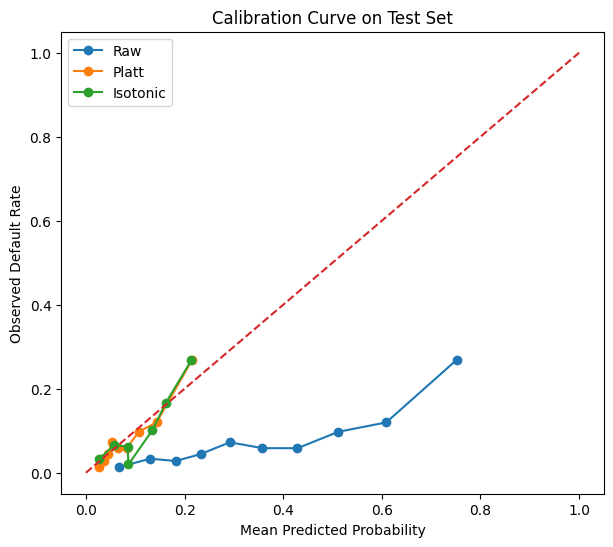

In [101]:
## Calibration Curves

plt.figure(figsize=(7, 6))

for name, probs in [
    ("Raw", test_raw),
    ("Platt", test_platt),
    ("Isotonic", test_iso),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve on Test Set")
plt.legend()
plt.show()

In [102]:
# Decile PD vs Observed Default Rate

def decile_calibration_table(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob}).copy()
    df["decile"] = pd.qcut(df["y_prob"], q=n_bins, duplicates="drop")
    out = df.groupby("decile").agg(
        count=("y_true", "size"),
        avg_pred_pd=("y_prob", "mean"),
        observed_default_rate=("y_true", "mean")
    ).reset_index()
    return out

print("Raw probability decile table:")
print(decile_calibration_table(y_test, test_raw))

print("\nPlatt calibrated decile table:")
print(decile_calibration_table(y_test, test_platt))

print("\nIsotonic calibrated decile table:")
print(decile_calibration_table(y_test, test_iso))

Raw probability decile table:
                          decile  count  avg_pred_pd  observed_default_rate
0  (0.011699999999999999, 0.103]    360     0.067917               0.013889
1                 (0.103, 0.159]    359     0.130711               0.033426
2                 (0.159, 0.205]    359     0.182135               0.027855
3                  (0.205, 0.26]    360     0.232657               0.044444
4                  (0.26, 0.325]    359     0.291871               0.072423
5                 (0.325, 0.392]    359     0.357930               0.058496
6                 (0.392, 0.469]    360     0.428750               0.058333
7                 (0.469, 0.556]    359     0.512010               0.097493
8                 (0.556, 0.665]    359     0.608931               0.119777
9                 (0.665, 0.915]    360     0.752393               0.269444

Platt calibrated decile table:
             decile  count  avg_pred_pd  observed_default_rate
0  (0.0202, 0.0286]    360     0.025533

/tmp/ipykernel_25729/2244582147.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("decile").agg(
/tmp/ipykernel_25729/2244582147.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("decile").agg(
/tmp/ipykernel_25729/2244582147.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("decile").agg(


In [103]:
tuning_results_df.head()

,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,learning_rate,n_estimators,valid_auc,valid_prauc,score
14,4,30,0.8,0.7,1.0,0.5,0.03,300,0.723264,0.213724,0.358377
0,5,20,0.8,0.9,1.0,0.5,0.03,300,0.719311,0.212858,0.356720
15,5,30,0.8,0.7,0.0,0.5,0.03,500,0.716814,0.213074,0.356437
9,3,20,0.8,0.9,0.5,1.0,0.02,500,0.725938,0.210702,0.355890
19,3,10,0.9,0.7,1.0,0.5,0.03,500,0.723521,0.210905,0.355609


In [104]:
final_comparison_df

,Model,Valid ROC-AUC,Test ROC-AUC,Valid PR-AUC,Test PR-AUC
0,Static-Only XGBoost,0.7178,0.7172,0.1872,0.2134
1,"Hybrid XGBoost (TCN+Static, no SMOTE)",0.7187,0.7259,0.2046,0.2284
2,"Tuned Hybrid XGBoost (TCN+Static, no SMOTE)",0.7233,0.7273,0.2137,0.2256


In [105]:
calibration_results

,Calibration,Valid Brier,Test Brier,Valid ROC-AUC,Test ROC-AUC,Valid PR-AUC,Test PR-AUC
0,Raw,0.1665,0.1671,0.7233,0.7273,0.2137,0.2256
1,Platt,0.0695,0.0683,0.7233,0.7273,0.2137,0.2256
2,Isotonic,0.0675,0.0690,0.7326,0.7255,0.2111,0.2113


# 10. Final Evaluation: Discrimination, Calibration, and Stability

## 10.1 Define final benchmark and final candidate

In [106]:
# Benchmark model predictions
benchmark_valid_prob = y_pred_xgb_static_valid.copy()
benchmark_test_prob  = y_pred_xgb_static_test.copy()

# Final candidate raw predictions
final_valid_prob_raw = y_pred_xgb_hybrid_tuned_valid.copy()
final_test_prob_raw  = y_pred_xgb_hybrid_tuned_test.copy()

# Final candidate calibrated predictions (Platt)
final_valid_prob_cal = valid_platt.copy()
final_test_prob_cal  = test_platt.copy()

print("Prediction vectors ready:")
print("Benchmark valid/test:", benchmark_valid_prob.shape, benchmark_test_prob.shape)
print("Final raw valid/test:", final_valid_prob_raw.shape, final_test_prob_raw.shape)
print("Final cal valid/test:", final_valid_prob_cal.shape, final_test_prob_cal.shape)

Prediction vectors ready:
Benchmark valid/test: (3594,) (3594,)
Final raw valid/test: (3594,) (3594,)
Final cal valid/test: (3594,) (3594,)


In [108]:
## 10.2 Discrimination Metrics

discrimination_df = pd.DataFrame({
    "Model": [
        "Benchmark Static-Only XGBoost",
        "Final Hybrid XGBoost (Raw)",
        "Final Hybrid XGBoost (Platt-Calibrated)"
    ],
    "Valid ROC-AUC": [
        roc_auc_score(y_valid, benchmark_valid_prob),
        roc_auc_score(y_valid, final_valid_prob_raw),
        roc_auc_score(y_valid, final_valid_prob_cal)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, benchmark_test_prob),
        roc_auc_score(y_test, final_test_prob_raw),
        roc_auc_score(y_test, final_test_prob_cal)
    ],
    "Valid PR-AUC": [
        average_precision_score(y_valid, benchmark_valid_prob),
        average_precision_score(y_valid, final_valid_prob_raw),
        average_precision_score(y_valid, final_valid_prob_cal)
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, benchmark_test_prob),
        average_precision_score(y_test, final_test_prob_raw),
        average_precision_score(y_test, final_test_prob_cal)
    ]
}).round(4)

print(discrimination_df)

                                     Model  Valid ROC-AUC  Test ROC-AUC  \
0            Benchmark Static-Only XGBoost         0.7178        0.7172   
1               Final Hybrid XGBoost (Raw)         0.7233        0.7273   
2  Final Hybrid XGBoost (Platt-Calibrated)         0.7233        0.7273   

   Valid PR-AUC  Test PR-AUC  
0        0.1872       0.2134  
1        0.2137       0.2256  
2        0.2137       0.2256  


In [110]:
## 10.3 KS Statistic and Gini

def ks_statistic(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

def gini_from_auc(auc):
    return 2 * auc - 1

ks_gini_df = pd.DataFrame({
    "Model": [
        "Benchmark Static-Only XGBoost",
        "Final Hybrid XGBoost (Raw)",
        "Final Hybrid XGBoost (Platt-Calibrated)"
    ],
    "Valid KS": [
        ks_statistic(y_valid, benchmark_valid_prob),
        ks_statistic(y_valid, final_valid_prob_raw),
        ks_statistic(y_valid, final_valid_prob_cal)
    ],
    "Test KS": [
        ks_statistic(y_test, benchmark_test_prob),
        ks_statistic(y_test, final_test_prob_raw),
        ks_statistic(y_test, final_test_prob_cal)
    ],
    "Valid Gini": [
        gini_from_auc(roc_auc_score(y_valid, benchmark_valid_prob)),
        gini_from_auc(roc_auc_score(y_valid, final_valid_prob_raw)),
        gini_from_auc(roc_auc_score(y_valid, final_valid_prob_cal))
    ],
    "Test Gini": [
        gini_from_auc(roc_auc_score(y_test, benchmark_test_prob)),
        gini_from_auc(roc_auc_score(y_test, final_test_prob_raw)),
        gini_from_auc(roc_auc_score(y_test, final_test_prob_cal))
    ]
}).round(4)

print(ks_gini_df)

                                     Model  Valid KS  Test KS  Valid Gini  \
0            Benchmark Static-Only XGBoost    0.3440   0.3503      0.4356   
1               Final Hybrid XGBoost (Raw)    0.3523   0.3477      0.4465   
2  Final Hybrid XGBoost (Platt-Calibrated)    0.3523   0.3477      0.4465   

   Test Gini  
0     0.4345  
1     0.4545  
2     0.4545  


In [112]:
## 10.4 Decile Lift / Gains Analysis

def decile_lift_table(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob}).copy()
    df = df.sort_values("y_prob", ascending=False).reset_index(drop=True)
    df["decile"] = pd.qcut(np.arange(len(df)), q=n_bins, labels=[f"D{i}" for i in range(1, n_bins+1)])

    overall_rate = df["y_true"].mean()

    out = df.groupby("decile").agg(
        count=("y_true", "size"),
        defaults=("y_true", "sum"),
        observed_default_rate=("y_true", "mean"),
        avg_score=("y_prob", "mean")
    ).reset_index()

    out["lift"] = out["observed_default_rate"] / overall_rate
    out["cumulative_defaults"] = out["defaults"].cumsum()
    out["cumulative_capture_rate"] = out["cumulative_defaults"] / out["defaults"].sum()

    return out

print("Benchmark decile lift table:")
benchmark_deciles = decile_lift_table(y_test, benchmark_test_prob)
print(benchmark_deciles)

print("\nFinal hybrid raw decile lift table:")
final_raw_deciles = decile_lift_table(y_test, final_test_prob_raw)
print(final_raw_deciles)

print("\nFinal hybrid calibrated decile lift table:")
final_cal_deciles = decile_lift_table(y_test, final_test_prob_cal)
print(final_cal_deciles)

Benchmark decile lift table:
  decile  count  defaults  observed_default_rate  avg_score      lift  \
0     D1    360        78               0.216667   0.752245  2.722727   
1     D2    359        56               0.155989   0.607720  1.960224   
2     D3    359        37               0.103064   0.508876  1.295148   
3     D4    360        26               0.072222   0.428578  0.907576   
4     D5    359        23               0.064067   0.356582  0.805092   
5     D6    359        14               0.038997   0.288522  0.490056   
6     D7    360        19               0.052778   0.226058  0.663228   
7     D8    359        18               0.050139   0.166868  0.630072   
8     D9    359         7               0.019499   0.116020  0.245028   
9    D10    360         8               0.022222   0.053739  0.279254   

   cumulative_defaults  cumulative_capture_rate  
0                   78                 0.272727  
1                  134                 0.468531  
2                

/tmp/ipykernel_25729/2505867870.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("decile").agg(
/tmp/ipykernel_25729/2505867870.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("decile").agg(
/tmp/ipykernel_25729/2505867870.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("decile").agg(


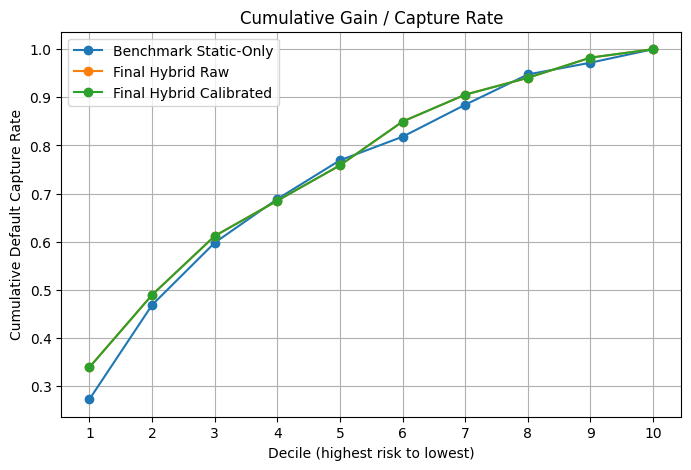

In [113]:
# Plot cumulative capture

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), benchmark_deciles["cumulative_capture_rate"], marker="o", label="Benchmark Static-Only")
plt.plot(range(1, 11), final_raw_deciles["cumulative_capture_rate"], marker="o", label="Final Hybrid Raw")
plt.plot(range(1, 11), final_cal_deciles["cumulative_capture_rate"], marker="o", label="Final Hybrid Calibrated")

plt.xlabel("Decile (highest risk to lowest)")
plt.ylabel("Cumulative Default Capture Rate")
plt.title("Cumulative Gain / Capture Rate")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()

In [116]:
# Calibration Metrics

def expected_calibration_error(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob}).copy()
    df["bin"] = pd.qcut(df["y_prob"], q=n_bins, duplicates="drop")

    ece = 0.0
    total = len(df)

    for _, grp in df.groupby("bin"):
        acc = grp["y_true"].mean()
        conf = grp["y_prob"].mean()
        ece += (len(grp) / total) * abs(acc - conf)

    return ece

calibration_df = pd.DataFrame({
    "Model": [
        "Benchmark Static-Only XGBoost",
        "Final Hybrid XGBoost (Raw)",
        "Final Hybrid XGBoost (Platt-Calibrated)"
    ],
    "Valid Brier": [
        brier_score_loss(y_valid, benchmark_valid_prob),
        brier_score_loss(y_valid, final_valid_prob_raw),
        brier_score_loss(y_valid, final_valid_prob_cal)
    ],
    "Test Brier": [
        brier_score_loss(y_test, benchmark_test_prob),
        brier_score_loss(y_test, final_test_prob_raw),
        brier_score_loss(y_test, final_test_prob_cal)
    ],
    "Valid ECE": [
        expected_calibration_error(y_valid, benchmark_valid_prob),
        expected_calibration_error(y_valid, final_valid_prob_raw),
        expected_calibration_error(y_valid, final_valid_prob_cal)
    ],
    "Test ECE": [
        expected_calibration_error(y_test, benchmark_test_prob),
        expected_calibration_error(y_test, final_test_prob_raw),
        expected_calibration_error(y_test, final_test_prob_cal)
    ]
}).round(4)

print(calibration_df)

                                     Model  Valid Brier  Test Brier  \
0            Benchmark Static-Only XGBoost       0.1657      0.1672   
1               Final Hybrid XGBoost (Raw)       0.1665      0.1671   
2  Final Hybrid XGBoost (Platt-Calibrated)       0.0695      0.0683   

   Valid ECE  Test ECE  
0     0.2660    0.2710  
1     0.2723    0.2770  
2     0.0084    0.0161  


/tmp/ipykernel_25729/2621016268.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in df.groupby("bin"):
/tmp/ipykernel_25729/2621016268.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in df.groupby("bin"):
/tmp/ipykernel_25729/2621016268.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in df.groupby("bin"):
/tmp/ipykernel_25729/2621016268.py:10: FutureWarning: The default of o

## 10.6 Calibration Curves

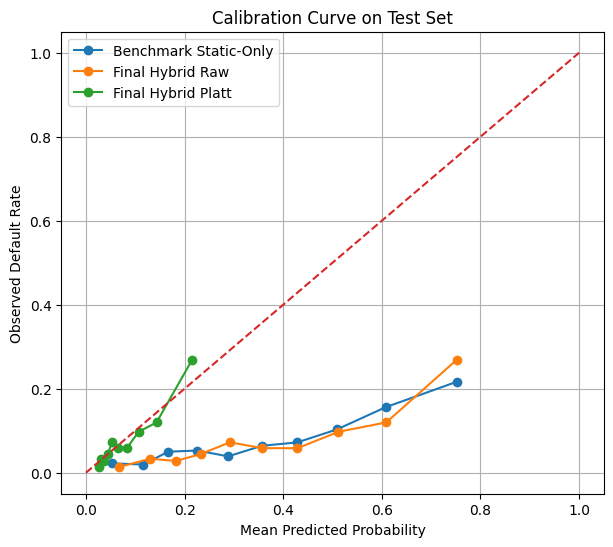

In [118]:
plt.figure(figsize=(7, 6))

for name, probs in [
    ("Benchmark Static-Only", benchmark_test_prob),
    ("Final Hybrid Raw", final_test_prob_raw),
    ("Final Hybrid Platt", final_test_prob_cal),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

## 10.7 Stability Assessment

In [119]:
stability_df = pd.DataFrame({
    "Model": [
        "Benchmark Static-Only XGBoost",
        "Final Hybrid XGBoost (Raw)",
        "Final Hybrid XGBoost (Platt-Calibrated)"
    ],
    "Valid ROC-AUC": [
        roc_auc_score(y_valid, benchmark_valid_prob),
        roc_auc_score(y_valid, final_valid_prob_raw),
        roc_auc_score(y_valid, final_valid_prob_cal)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, benchmark_test_prob),
        roc_auc_score(y_test, final_test_prob_raw),
        roc_auc_score(y_test, final_test_prob_cal)
    ],
    "ROC-AUC Gap": [
        abs(roc_auc_score(y_valid, benchmark_valid_prob) - roc_auc_score(y_test, benchmark_test_prob)),
        abs(roc_auc_score(y_valid, final_valid_prob_raw) - roc_auc_score(y_test, final_test_prob_raw)),
        abs(roc_auc_score(y_valid, final_valid_prob_cal) - roc_auc_score(y_test, final_test_prob_cal))
    ],
    "Valid PR-AUC": [
        average_precision_score(y_valid, benchmark_valid_prob),
        average_precision_score(y_valid, final_valid_prob_raw),
        average_precision_score(y_valid, final_valid_prob_cal)
    ],
    "Test PR-AUC": [
        average_precision_score(y_test, benchmark_test_prob),
        average_precision_score(y_test, final_test_prob_raw),
        average_precision_score(y_test, final_test_prob_cal)
    ],
    "PR-AUC Gap": [
        abs(average_precision_score(y_valid, benchmark_valid_prob) - average_precision_score(y_test, benchmark_test_prob)),
        abs(average_precision_score(y_valid, final_valid_prob_raw) - average_precision_score(y_test, final_test_prob_raw)),
        abs(average_precision_score(y_valid, final_valid_prob_cal) - average_precision_score(y_test, final_test_prob_cal))
    ]
}).round(4)

print(stability_df)

                                     Model  Valid ROC-AUC  Test ROC-AUC  \
0            Benchmark Static-Only XGBoost         0.7178        0.7172   
1               Final Hybrid XGBoost (Raw)         0.7233        0.7273   
2  Final Hybrid XGBoost (Platt-Calibrated)         0.7233        0.7273   

   ROC-AUC Gap  Valid PR-AUC  Test PR-AUC  PR-AUC Gap  
0       0.0006        0.1872       0.2134      0.0262  
1       0.0040        0.2137       0.2256      0.0119  
2       0.0040        0.2137       0.2256      0.0119  


In [121]:
# PSI for score distribution shift

def calculate_psi(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    breakpoints = np.percentile(expected, np.arange(0, bins + 1) * 100 / bins)
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    # convert to Series first for compatibility
    expected_dist = pd.Series(expected_bins).value_counts(sort=False) / len(expected_bins)
    actual_dist = pd.Series(actual_bins).value_counts(sort=False) / len(actual_bins)

    psi_df = pd.DataFrame({
        "expected_pct": expected_dist,
        "actual_pct": actual_dist
    }).fillna(1e-6)

    psi_df["psi_component"] = (
        (psi_df["actual_pct"] - psi_df["expected_pct"]) *
        np.log((psi_df["actual_pct"] + 1e-6) / (psi_df["expected_pct"] + 1e-6))
    )

    return psi_df["psi_component"].sum()

psi_df = pd.DataFrame({
    "Model": [
        "Benchmark Static-Only XGBoost",
        "Final Hybrid XGBoost (Raw)",
        "Final Hybrid XGBoost (Platt-Calibrated)"
    ],
    "PSI Valid->Test": [
        calculate_psi(benchmark_valid_prob, benchmark_test_prob),
        calculate_psi(final_valid_prob_raw, final_test_prob_raw),
        calculate_psi(final_valid_prob_cal, final_test_prob_cal)
    ]
}).round(4)

print(psi_df)

                                     Model  PSI Valid->Test
0            Benchmark Static-Only XGBoost           0.0037
1               Final Hybrid XGBoost (Raw)           0.0060
2  Final Hybrid XGBoost (Platt-Calibrated)           0.0060


## 10.8 Final Evaluation Summary

In [122]:
final_eval_summary = discrimination_df.merge(
    ks_gini_df, on="Model"
).merge(
    calibration_df, on="Model"
).merge(
    psi_df, on="Model"
).round(4)

print(final_eval_summary)

                                     Model  Valid ROC-AUC  Test ROC-AUC  \
0            Benchmark Static-Only XGBoost         0.7178        0.7172   
1               Final Hybrid XGBoost (Raw)         0.7233        0.7273   
2  Final Hybrid XGBoost (Platt-Calibrated)         0.7233        0.7273   

   Valid PR-AUC  Test PR-AUC  Valid KS  Test KS  Valid Gini  Test Gini  \
0        0.1872       0.2134    0.3440   0.3503      0.4356     0.4345   
1        0.2137       0.2256    0.3523   0.3477      0.4465     0.4545   
2        0.2137       0.2256    0.3523   0.3477      0.4465     0.4545   

   Valid Brier  Test Brier  Valid ECE  Test ECE  PSI Valid->Test  
0       0.1657      0.1672     0.2660    0.2710           0.0037  
1       0.1665      0.1671     0.2723    0.2770           0.0060  
2       0.0695      0.0683     0.0084    0.0161           0.0060  


In [124]:
discrimination_df

,Model,Valid ROC-AUC,Test ROC-AUC,Valid PR-AUC,Test PR-AUC
0,Benchmark Static-Only XGBoost,0.7178,0.7172,0.1872,0.2134
1,Final Hybrid XGBoost (Raw),0.7233,0.7273,0.2137,0.2256
2,Final Hybrid XGBoost (Platt-Calibrated),0.7233,0.7273,0.2137,0.2256


In [125]:
ks_gini_df

,Model,Valid KS,Test KS,Valid Gini,Test Gini
0,Benchmark Static-Only XGBoost,0.3440,0.3503,0.4356,0.4345
1,Final Hybrid XGBoost (Raw),0.3523,0.3477,0.4465,0.4545
2,Final Hybrid XGBoost (Platt-Calibrated),0.3523,0.3477,0.4465,0.4545


In [126]:
calibration_df

,Model,Valid Brier,Test Brier,Valid ECE,Test ECE
0,Benchmark Static-Only XGBoost,0.1657,0.1672,0.2660,0.2710
1,Final Hybrid XGBoost (Raw),0.1665,0.1671,0.2723,0.2770
2,Final Hybrid XGBoost (Platt-Calibrated),0.0695,0.0683,0.0084,0.0161


In [127]:
stability_df

,Model,Valid ROC-AUC,Test ROC-AUC,ROC-AUC Gap,Valid PR-AUC,Test PR-AUC,PR-AUC Gap
0,Benchmark Static-Only XGBoost,0.7178,0.7172,0.0006,0.1872,0.2134,0.0262
1,Final Hybrid XGBoost (Raw),0.7233,0.7273,0.0040,0.2137,0.2256,0.0119
2,Final Hybrid XGBoost (Platt-Calibrated),0.7233,0.7273,0.0040,0.2137,0.2256,0.0119


In [128]:
psi_df

,Model,PSI Valid->Test
0,Benchmark Static-Only XGBoost,0.0037
1,Final Hybrid XGBoost (Raw),0.0060
2,Final Hybrid XGBoost (Platt-Calibrated),0.0060


# 11. Business Decision Layer: High-Risk Borrower Identification and Credit Policy Bands

## 11.1 Borrower-Level Risk Table

In [130]:
risk_table = pd.DataFrame({
    "SK_ID_CURR": id_test,
    "actual_default": y_test,
    "pd_raw": final_test_prob_raw,
    "pd_calibrated": final_test_prob_cal
}).copy()

risk_table = risk_table.sort_values("pd_calibrated", ascending=False).reset_index(drop=True)

print("Risk table preview:")
print(risk_table.head(10))
print("\nShape:", risk_table.shape)

Risk table preview:
   SK_ID_CURR  actual_default    pd_raw  pd_calibrated
0      314731               0  0.915185       0.321776
1      156066               0  0.913507       0.320524
2      221039               1  0.905970       0.314934
3      133840               1  0.901480       0.311629
4      154527               1  0.894722       0.306691
5      122861               1  0.893087       0.305502
6      218614               0  0.889468       0.302882
7      187156               1  0.888436       0.302137
8      398535               0  0.880189       0.296221
9      257597               0  0.876365       0.293500

Shape: (3594, 4)


## 11.2 High-Risk Borrower Identification

In [131]:
TOP_N = 100

top_high_risk = risk_table.head(TOP_N).copy()

print(f"Top {TOP_N} highest-risk borrowers:")
print(top_high_risk[["SK_ID_CURR", "pd_calibrated", "actual_default"]].head(20))

high_risk_summary = {
    "top_n": TOP_N,
    "avg_pd_top_n": top_high_risk["pd_calibrated"].mean(),
    "observed_default_rate_top_n": top_high_risk["actual_default"].mean(),
    "overall_default_rate_test": risk_table["actual_default"].mean()
}

print("\nHigh-risk summary:")
for k, v in high_risk_summary.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Top 100 highest-risk borrowers:
    SK_ID_CURR  pd_calibrated  actual_default
0       314731       0.321776               0
1       156066       0.320524               0
2       221039       0.314934               1
3       133840       0.311629               1
4       154527       0.306691               1
5       122861       0.305502               1
6       218614       0.302882               0
7       187156       0.302137               1
8       398535       0.296221               0
9       257597       0.293500               0
10      207415       0.291087               0
11      228927       0.289435               0
12      301114       0.289008               0
13      273439       0.288370               1
14      452710       0.287427               1
15      238567       0.285099               1
16      268561       0.284284               0
17      366331       0.282732               0
18      330453       0.281558               0
19      325842       0.281013               1

H

## 11.3 Risk Band Construction

In [132]:
risk_table["risk_band"] = pd.qcut(
    risk_table["pd_calibrated"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

band_summary = risk_table.groupby("risk_band").agg(
    borrower_count=("SK_ID_CURR", "count"),
    avg_predicted_pd=("pd_calibrated", "mean"),
    observed_default_rate=("actual_default", "mean"),
    min_pd=("pd_calibrated", "min"),
    max_pd=("pd_calibrated", "max")
).reset_index()

print("Risk band summary:")
print(band_summary)

Risk band summary:
   risk_band  borrower_count  avg_predicted_pd  observed_default_rate  \
0   Very Low             719          0.028475               0.023644   
1        Low             719          0.040599               0.036161   
2     Medium             718          0.059652               0.065460   
3       High             719          0.094771               0.077886   
4  Very High             719          0.179449               0.194715   

     min_pd    max_pd  
0  0.021178  0.034455  
1  0.034483  0.048068  
2  0.048074  0.073270  
3  0.073307  0.122066  
4  0.122079  0.321776  


/tmp/ipykernel_25729/3932394921.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_summary = risk_table.groupby("risk_band").agg(


## 11.4 Visualize Risk Bands

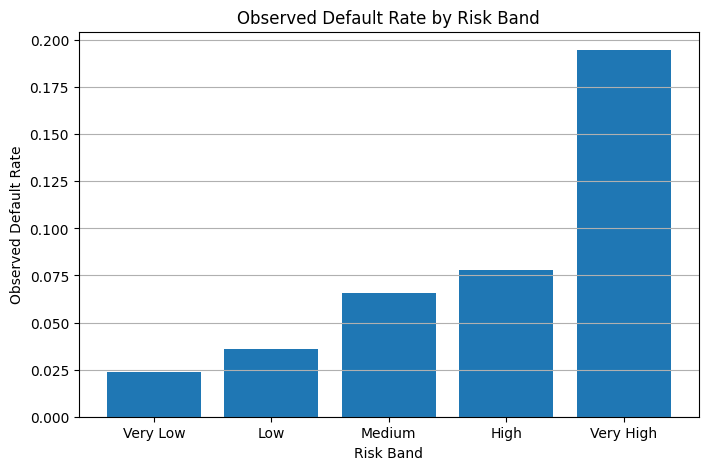

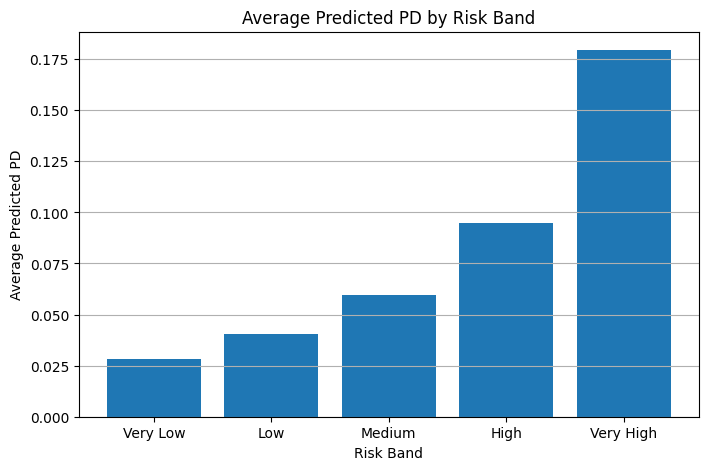

In [133]:
plt.figure(figsize=(8, 5))
plt.bar(band_summary["risk_band"], band_summary["observed_default_rate"])
plt.title("Observed Default Rate by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Observed Default Rate")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(band_summary["risk_band"], band_summary["avg_predicted_pd"])
plt.title("Average Predicted PD by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Average Predicted PD")
plt.grid(axis="y")
plt.show()

## 11.5 Approval / Review / Reject Policy Simulation

In [134]:
decision_map = {
    "Very Low": "Approve",
    "Low": "Approve",
    "Medium": "Review",
    "High": "Reject",
    "Very High": "Reject"
}

risk_table["decision_band"] = risk_table["risk_band"].map(decision_map)

decision_summary = risk_table.groupby("decision_band").agg(
    borrower_count=("SK_ID_CURR", "count"),
    avg_predicted_pd=("pd_calibrated", "mean"),
    observed_default_rate=("actual_default", "mean")
).reset_index()

decision_summary["share_of_portfolio"] = decision_summary["borrower_count"] / len(risk_table)

print("Decision band summary:")
print(decision_summary)

Decision band summary:
  decision_band  borrower_count  avg_predicted_pd  observed_default_rate  \
0       Approve            1438          0.034537               0.029903   
1        Reject            1438          0.137110               0.136300   
2        Review             718          0.059652               0.065460   

   share_of_portfolio  
0            0.400111  
1            0.400111  
2            0.199777  


## 11.6 Policy Outcome View

In [135]:
policy_outcome = risk_table.groupby(["decision_band", "actual_default"]).size().unstack(fill_value=0)
policy_outcome.columns = ["actual_non_default", "actual_default"] if len(policy_outcome.columns) == 2 else policy_outcome.columns

print("Policy outcome table:")
print(policy_outcome)

# Add rates
policy_outcome_rate = policy_outcome.div(policy_outcome.sum(axis=1), axis=0)
print("\nPolicy outcome rates within each decision band:")
print(policy_outcome_rate)

Policy outcome table:
               actual_non_default  actual_default
decision_band                                    
Approve                      1395              43
Reject                       1242             196
Review                        671              47

Policy outcome rates within each decision band:
               actual_non_default  actual_default
decision_band                                    
Approve                  0.970097        0.029903
Reject                   0.863700        0.136300
Review                   0.934540        0.065460


## 11.7 Threshold-Based Policy Alternative

In [136]:
def assign_policy_from_pd(pd_value):
    if pd_value < 0.05:
        return "Approve"
    elif pd_value < 0.15:
        return "Review"
    else:
        return "Reject"

risk_table["decision_pd_threshold"] = risk_table["pd_calibrated"].apply(assign_policy_from_pd)

threshold_policy_summary = risk_table.groupby("decision_pd_threshold").agg(
    borrower_count=("SK_ID_CURR", "count"),
    avg_predicted_pd=("pd_calibrated", "mean"),
    observed_default_rate=("actual_default", "mean")
).reset_index()

threshold_policy_summary["share_of_portfolio"] = threshold_policy_summary["borrower_count"] / len(risk_table)

print("Threshold-based decision summary:")
print(threshold_policy_summary)

Threshold-based decision summary:
  decision_pd_threshold  borrower_count  avg_predicted_pd  \
0               Approve            1512          0.035251   
1                Reject             484          0.201081   
2                Review            1598          0.087006   

   observed_default_rate  share_of_portfolio  
0               0.032407            0.420701  
1               0.239669            0.134669  
2               0.075720            0.444630  


## 11.8 Compare Policy Approaches

In [137]:
print("Band-based policy summary:")
print(decision_summary)

print("\nThreshold-based policy summary:")
print(threshold_policy_summary)

Band-based policy summary:
  decision_band  borrower_count  avg_predicted_pd  observed_default_rate  \
0       Approve            1438          0.034537               0.029903   
1        Reject            1438          0.137110               0.136300   
2        Review             718          0.059652               0.065460   

   share_of_portfolio  
0            0.400111  
1            0.400111  
2            0.199777  

Threshold-based policy summary:
  decision_pd_threshold  borrower_count  avg_predicted_pd  \
0               Approve            1512          0.035251   
1                Reject             484          0.201081   
2                Review            1598          0.087006   

   observed_default_rate  share_of_portfolio  
0               0.032407            0.420701  
1               0.239669            0.134669  
2               0.075720            0.444630  


## 11.9 Export Outputs

In [138]:
output_dir = os.path.join(BASE_DIR, "business_decision_outputs")
os.makedirs(output_dir, exist_ok=True)

risk_table.to_csv(os.path.join(output_dir, "risk_table_test_set.csv"), index=False)
top_high_risk.to_csv(os.path.join(output_dir, f"top_{TOP_N}_high_risk_borrowers.csv"), index=False)
band_summary.to_csv(os.path.join(output_dir, "risk_band_summary.csv"), index=False)
decision_summary.to_csv(os.path.join(output_dir, "decision_band_summary.csv"), index=False)
threshold_policy_summary.to_csv(os.path.join(output_dir, "threshold_policy_summary.csv"), index=False)

print(f"Saved outputs to: {output_dir}")

Saved outputs to: /content/drive/MyDrive/self learning/Self Project/Credit Rating Model/dataset/home_credit_subset/business_decision_outputs


In [139]:
band_summary

,risk_band,borrower_count,avg_predicted_pd,observed_default_rate,min_pd,max_pd
0,Very Low,719,0.028475,0.023644,0.021178,0.034455
1,Low,719,0.040599,0.036161,0.034483,0.048068
2,Medium,718,0.059652,0.065460,0.048074,0.073270
3,High,719,0.094771,0.077886,0.073307,0.122066
4,Very High,719,0.179449,0.194715,0.122079,0.321776


In [140]:
decision_summary

,decision_band,borrower_count,avg_predicted_pd,observed_default_rate,share_of_portfolio
0,Approve,1438,0.034537,0.029903,0.400111
1,Reject,1438,0.137110,0.136300,0.400111
2,Review,718,0.059652,0.065460,0.199777


In [141]:
threshold_policy_summary

,decision_pd_threshold,borrower_count,avg_predicted_pd,observed_default_rate,share_of_portfolio
0,Approve,1512,0.035251,0.032407,0.420701
1,Reject,484,0.201081,0.239669,0.134669
2,Review,1598,0.087006,0.075720,0.444630


In [142]:
high_risk_summary

{'top_n': 100,
 'avg_pd_top_n': np.float64(0.2618638723887485),
 'observed_default_rate_top_n': np.float64(0.4),
 'overall_default_rate_test': np.float64(0.07957707289927657)}